In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from tslearn.metrics import cdist_dtw
from helper_plots import plot_pseudotime_for_cells
from pathlib import Path

def sample_rows_per_cluster(df, cluster_col, n=5, random_state=42):
    return (
        df
        .groupby(cluster_col, group_keys=False)
        .apply(lambda x: x.sample(min(n, len(x)), random_state=random_state))
    )


def compute_mean_std(ts_list):
    ts_list = [np.asarray(ts, dtype=float) for ts in ts_list]
    max_len = max(len(ts) for ts in ts_list)
    aligned = [
        np.pad(ts, (0, max_len - len(ts)), constant_values=np.nan)
        for ts in ts_list
    ]
    mat = np.vstack(aligned)
    return np.nanmean(mat, axis=0), np.nanstd(mat, axis=0)

def plot_kmeans_mean_shapes(X, labels):
    plt.figure(figsize=(12,6))

    for lab in sorted(set(labels)):
        idx = np.where(labels == lab)[0]
        ts_list = [X[i] for i in idx]

        mean_ts, std_ts = compute_mean_std(ts_list)
        t = np.arange(len(mean_ts))

        plt.plot(t, mean_ts, label=f"Cluster {lab}", linewidth=2)
        plt.fill_between(t, mean_ts - std_ts, mean_ts + std_ts, alpha=0.2)

    plt.title("KMeans Mean Shape per Cluster (± STD)")
    plt.legend()
    plt.show()

In [2]:

SD_clean = pd.read_pickle("checkpoints/pseudotime_cells_clean_1476.pkl")

n = 6  # minimum required length

SD_clean = SD_clean[SD_clean["pseudotime_widths"].apply(len) >= n]


outliers = []
with open(r"datasets\1476_dapi_python_segmentation_outliers.txt", "r") as f:
    for line in f:
        outliers.append(line.strip() +".tif")

print(outliers)

SD_clean = SD_clean[
    ~SD_clean["path_dapi"].apply(lambda p: Path(p).name).isin(outliers)
]


#X = SD_clean["pseudotime_widths"].to_list()

SD_clean

['obj6270001_stainDAPI.tif', 'obj6290001_stainDAPI.tif', 'obj6560001_stainDAPI.tif', 'obj6680001_stainDAPI.tif', 'obj6700001_stainDAPI.tif', 'obj6760006_stainDAPI.tif', 'obj6760006_stainDAPI.tif', 'obj6840001_stainDAPI.tif', 'obj7550001_stainDAPI.tif', 'obj7560001_stainDAPI.tif', 'obj7560005_stainDAPI.tif', 'obj7560056_stainDAPI.tif', 'obj7580001_stainDAPI.tif', 'obj7580003_stainDAPI.tif', 'obj8090003_stainDAPI.tif', 'obj8600002_stainDAPI.tif', 'obj2780002_stainDAPI.tif', 'obj2840002_stainDAPI.tif', 'obj2840005_stainDAPI.tif', 'obj2970002_stainDAPI.tif', 'obj3190001_stainDAPI.tif', 'obj3250002_stainDAPI.tif', 'obj3530001_stainDAPI.tif', 'obj3530002_stainDAPI.tif', 'obj3530003_stainDAPI.tif', 'obj3530004_stainDAPI.tif', 'obj3800002_stainDAPI.tif', 'obj3810001_stainDAPI.tif', 'obj3900002_stainDAPI.tif', 'obj4040002_stainDAPI.tif', 'obj4440001_stainDAPI.tif', 'obj4770001_stainDAPI.tif', 'obj4890002_stainDAPI.tif', 'obj5180002_stainDAPI.tif', 'obj6020001_stainDAPI.tif', 'obj50001_stainDAPI

,path_background,path_dapi,path_yap,path_actin,height,width,channels,radial_distribution.RadialDistribution_FracAtD_1of4,radial_distribution.RadialDistribution_MeanFrac_1of4,radial_distribution.RadialDistribution_RadialCV_1of4,...,centered_bbox_min_y,centered_bbox_max_x,centered_bbox_max_y,bbox_rot_min_x,bbox_rot_min_y,bbox_rot_max_x,bbox_rot_max_y,pseudotime,pseudotime_widths,pseudotime_center_bin
obj_id,,,,,,,,,,,,,,,,,,,,,
10001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.230345,3.731586,0.557365,...,33.5,-37.5,45.5,-56.791968,21.514013,-44.271813,35.513279,"[11, 12, 13, 14, 15, 16, 0, 0]","[6, 6, 7, 8, 12, 14, 18, 15]",14
20001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.537209,17.958140,0.057723,...,5.5,-30.5,16.5,-62.679214,-8.743934,-30.942156,8.941564,"[8, 9, 10, 11, 12, 13, 14, 15, 16, 0, 1, 2, 3,...","[3, 4, 5, 6, 7, 7, 8, 11, 14, 18, 16, 13, 11, ...",0
30001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.104247,2.147490,0.461122,...,31.5,-38.5,48.5,-67.215697,17.239667,-44.778433,38.197819,"[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 0]","[8, 4, 4, 4, 6, 6, 6, 7, 8, 12, 14, 18]",12
40001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.311155,11.326027,0.061208,...,-26.5,96.5,-15.5,74.116182,-8.883164,100.018289,7.404717,"[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 0, 1, 2, 3]","[4, 3, 6, 6, 6, 7, 7, 9, 11, 10, 19, 15, 12, 11]",14
50002,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.196970,5.278788,0.287822,...,-79.5,-5.5,-55.5,-21.595508,-85.582351,13.169722,-55.254456,"[11, 12, 13, 14, 15, 16, 0, 0, 1, 2, 3, 4, 5, ...","[7, 8, 8, 9, 12, 10, 18, 15, 12, 12, 11, 9, 6,...",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8570001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.421150,14.693465,0.409134,...,-23.5,79.5,3.5,54.130522,-9.692667,82.787116,21.922150,"[15, 16, 0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]","[11, 15, 19, 17, 14, 13, 11, 10, 9, 5, 4, 3, 6...",4
8580001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.294118,10.470588,0.482305,...,-44.5,8.5,-30.5,-9.914056,-47.352278,18.631843,-27.681049,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[18, 16, 12, 12, 11, 10, 7, 5, 5, 4, 5, 6, 7, ...",8
8590001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.364063,11.467969,0.069561,...,-9.5,15.5,8.5,-10.246140,-11.218632,17.286520,11.876693,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]","[17, 15, 12, 12, 10, 9, 6, 4, 4, 5, 5, 7, 8, 8]",6


In [3]:
df_identifyPrimaryObjects = pd.read_csv("datasets/1476/MyExpt_IdentifyPrimaryObjects.csv")
df_Phalloidin_segmented = pd.read_csv("datasets/1476/MyExpt_Phalloidin_segmented.csv")
df_YAP_segmented = pd.read_csv("datasets/1476/MyExpt_YAP_segmented.csv")

SD_clean["ImageNumber"] = SD_clean.index // 10000
SD_clean["ObjectNumber"] = SD_clean.index % 10000

keys = ["Metadata_ObjNumber", "ObjectNumber"]

cluster_map = SD_clean.rename(columns={"ImageNumber": "Metadata_ObjNumber"})

def prepare_df(df, prefix, keys):
    # rename all non-key columns with a prefix
    rename_dict = {
        col: f"{prefix}_{col}"
        for col in df.columns
        if col not in keys
    }
    return df.rename(columns=rename_dict)

# prefix each dataframe to avoid collisions
df_id = prepare_df(df_identifyPrimaryObjects, "dapi", keys)
df_ph = prepare_df(df_Phalloidin_segmented, "phalloidin", keys)
df_yap = prepare_df(df_YAP_segmented, "yap", keys)

# merge everything into one dataframe
SD_clean = (
    cluster_map
    .merge(df_id, on=keys, how="inner")
    .merge(df_ph, on=keys, how="inner")
    .merge(df_yap, on=keys, how="inner")
)

X = SD_clean["pseudotime_widths"].to_list()

SD_clean

,path_background,path_dapi,path_yap,path_actin,height,width,channels,radial_distribution.RadialDistribution_FracAtD_1of4,radial_distribution.RadialDistribution_MeanFrac_1of4,radial_distribution.RadialDistribution_RadialCV_1of4,...,yap_Texture_Variance_DNA_3_03_256,yap_Texture_Variance_Phalloidin_3_00_256,yap_Texture_Variance_Phalloidin_3_01_256,yap_Texture_Variance_Phalloidin_3_02_256,yap_Texture_Variance_Phalloidin_3_03_256,yap_Texture_Variance_YAP_3_00_256,yap_Texture_Variance_YAP_3_01_256,yap_Texture_Variance_YAP_3_02_256,yap_Texture_Variance_YAP_3_03_256,yap_QC_classification
0,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.537209,17.958140,0.057723,...,94.014171,23.305839,22.507342,23.431059,22.814243,8.366343,9.176352,9.054322,8.476505,positive
1,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.104247,2.147490,0.461122,...,233.406870,286.677944,301.280466,291.057696,291.839245,50.375533,53.919633,52.108475,51.865701,positive
2,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.311155,11.326027,0.061208,...,183.736593,308.285271,332.203139,320.907050,317.314944,52.011382,58.500451,54.999081,52.606304,positive
3,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.195251,4.523307,0.055161,...,610.666882,153.619439,163.516134,154.823560,155.221458,141.276650,157.147377,142.909829,143.360798,positive
4,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.117794,3.604511,0.017205,...,416.798159,169.445586,182.684224,177.405454,173.542274,90.940738,109.528681,99.203579,96.056896,positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
662,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.388795,10.843048,0.038592,...,1740.955816,198.198814,204.683202,201.437313,200.550414,63.539021,66.412769,64.155889,64.934491,positive
663,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.090667,4.049778,0.563025,...,566.190529,344.045933,376.874891,359.581337,355.002085,34.429875,36.895302,35.568476,35.923558,positive
664,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.082474,2.686303,0.403961,...,594.926166,522.392841,586.523457,557.170293,546.395895,104.914706,120.586041,112.769419,111.173651,positive
665,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.151858,2.919045,0.562581,...,2293.469776,187.708794,202.050553,188.364564,191.127150,83.9

In [4]:
from sklearn.cluster import KMeans


features = [
    [
        np.mean(ts),
        np.std(ts),
        # np.max(ts),
        # np.min(ts),
        len(ts)
    ]
    for ts in X
]

# #ignore class 3(grenn)
kmeans = KMeans(n_clusters=4, random_state=42)
# kmeans.fit(features)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

pca = PCA(n_components=3)
X_embedded = pca.fit_transform(X_scaled)

kmeans.fit(X_embedded)


,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


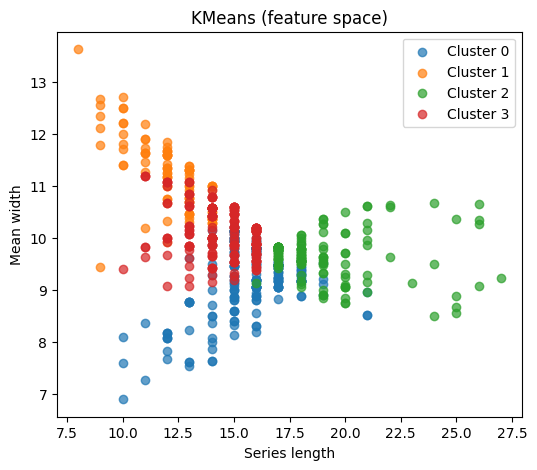

In [5]:
labels_kmeans = kmeans.labels_

features = np.array(features)

plt.figure(figsize=(6, 5))
for c in np.unique(labels_kmeans):
    idx = labels_kmeans == c
    plt.scatter(
        features[idx, -1],     # length
        features[idx, 0],      # mean
        label=f"Cluster {c}",
        alpha=0.7
    )

plt.xlabel("Series length")
plt.ylabel("Mean width")
plt.title("KMeans (feature space)")
plt.legend()
plt.show()

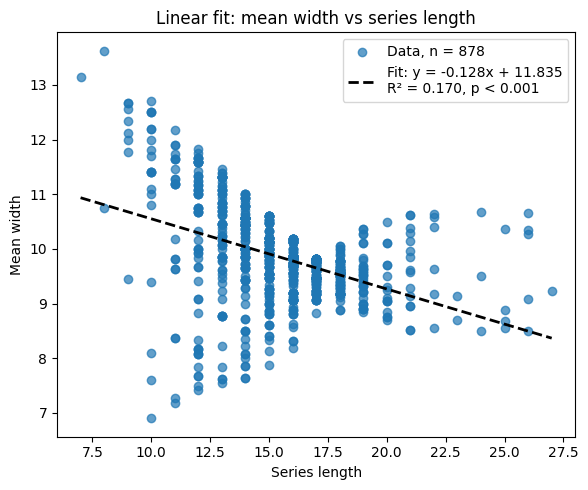

2.991585085859754e-37


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

X = SD_clean["pseudotime_widths"].to_list()
# Extract features you actually want to plot
lengths = np.array([len(ts) for ts in X], dtype=float)
means = np.array([np.mean(ts) for ts in X], dtype=float)

# Remove invalid values, just in case
valid = np.isfinite(lengths) & np.isfinite(means)
lengths = lengths[valid]
means = means[valid]

# Sample size
n = len(lengths)

# Fit linear regression with p-value
result = linregress(lengths, means)

slope = result.slope
intercept = result.intercept
r_value = result.rvalue
p_value = result.pvalue
r2 = r_value ** 2

# Smooth line for plotting
x_line = np.linspace(lengths.min(), lengths.max(), 200)
y_line = slope * x_line + intercept

# Format p-value nicely
if p_value < 0.001:
    p_text = "p < 0.001"
else:
    p_text = f"p = {p_value:.3f}"

# Plot
plt.figure(figsize=(6, 5))

plt.scatter(
    lengths,
    means,
    alpha=0.7,
    label=f"Data, n = {n}"
)

plt.plot(
    x_line,
    y_line,
    "k--",
    linewidth=2,
    label=(
        f"Fit: y = {slope:.3f}x + {intercept:.3f}\n"
        f"R² = {r2:.3f}, {p_text}"
    )
)

plt.xlabel("Series length")
plt.ylabel("Mean width")
plt.title("Linear fit: mean width vs series length")
plt.legend()
plt.tight_layout()
plt.show()


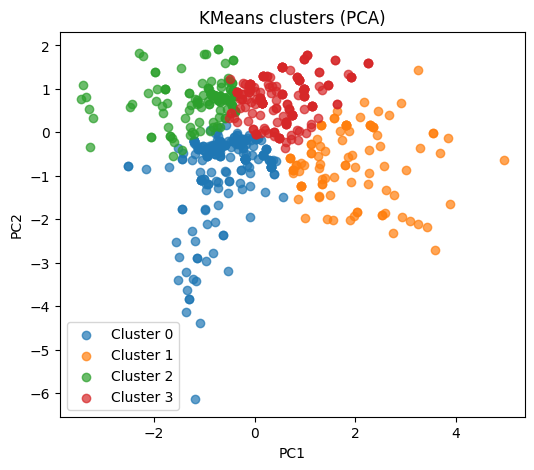

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(features)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
for c in np.unique(labels_kmeans):
    idx = labels_kmeans == c
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"Cluster {c}", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans clusters (PCA)")
plt.legend()
plt.show()

In [ ]:
SD_clean['cluster_kmeans'] = labels_kmeans

df_kmeans_samples = sample_rows_per_cluster(
    SD_clean,
    cluster_col='cluster_kmeans',
    n=5
)

df_kmeans_samples

plot_pseudotime_for_cells(df_kmeans_samples.query('cluster_kmeans == 0'), num_cells=5)
plot_pseudotime_for_cells(df_kmeans_samples.query('cluster_kmeans == 1'), num_cells=5)
#plot_pseudotime_for_cells(df_kmeans_samples.query('cluster_kmeans == 2'), num_cells=5)

NameError: name 'labels_kmeans' is not defined

In [8]:
import seaborn as sns

feats = ['AreaShape_FormFactor', 'AreaShape_Extent','AreaShape_MinorAxisLength',
         'AreaShape_Eccentricity',  'AreaShape_Perimeter', 'AreaShape_Compactness', 
         'AreaShape_MajorAxisLength', 'AreaShape_Orientation',
         'AreaShape_Area','AreaShape_Solidity',
        ]

def name_in_df(feat):
    return  'sizeshape.' + feat.split('_')[1]

feats_CPmeasure = []
for feat in feats:
    col = name_in_df(feat)
    if col in SD_clean.columns:
        feats_CPmeasure.append(col)
    else:
        print(f"Feature {name_in_df(feat)} not found in dataframe")


SD_clean[feats_CPmeasure + ['cluster_kmeans']].groupby('cluster_kmeans').mean()

sns.heatmap( SD_clean[feats_CPmeasure + ['cluster_kmeans']] .groupby('cluster_kmeans') .mean() .T, cmap="viridis", annot=True, fmt=".2f" )

KeyError: "['cluster_kmeans'] not in index"

<Axes: xlabel='cluster_kmeans'>

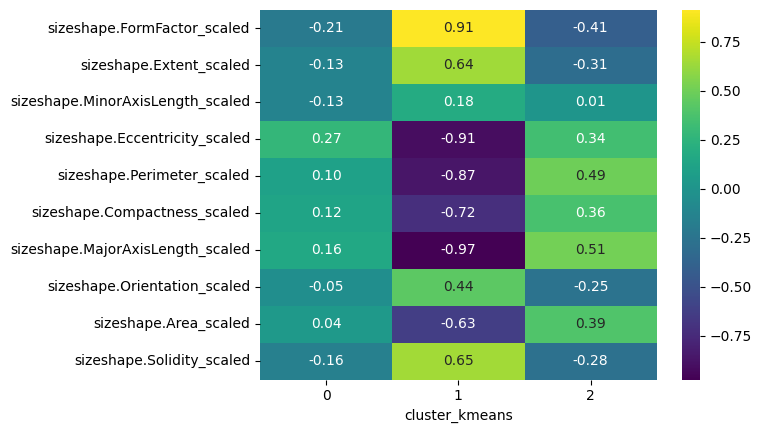

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(SD_clean[feats_CPmeasure])

feats_CPmeasure_scaled = [f + "_scaled" for f in feats_CPmeasure]

SD_clean[feats_CPmeasure_scaled] = scaled



sns.heatmap(
    SD_clean[feats_CPmeasure_scaled + ['cluster_kmeans']]
    .groupby('cluster_kmeans')
    .mean()
    .T,
    cmap="viridis",
    annot=True,
    fmt=".2f"
)

In [9]:
from sklearn.metrics import silhouette_samples

s = silhouette_samples(X_scaled, labels_kmeans)
for k in np.unique(labels_kmeans):
    print(k, s[labels_kmeans == k].mean())

X_kmeans = SD_clean["pseudotime_widths"].to_list()
labels_kmeans = SD_clean["cluster_kmeans"].values

plot_kmeans_mean_shapes(X_kmeans, labels_kmeans)  

0 0.24756844371823125
1 0.3054613240862355
2 0.3108494400377819
3 0.3469113983271352


KeyError: 'cluster_kmeans'

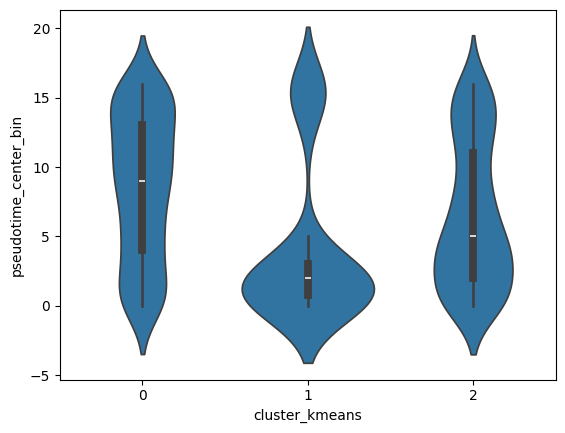

In [ ]:
sns.violinplot(x='cluster_kmeans', y='pseudotime_center_bin', data=SD_clean)
plt.show()

In [10]:
mask = labels_kmeans != 2
features_no_outliers = features[mask]
X_scaled_no_Outliers = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
labels_clean = kmeans.fit_predict(X_scaled_no_Outliers)
    
s_clean = silhouette_samples(X_scaled_no_Outliers, labels_clean)

for k in np.unique(labels_clean):
    print(k, s_clean[labels_clean == k].mean())


0 0.2754330457462269
1 0.22669612720808138
2 0.3373323393064402


<Axes: xlabel='cluster_kmeans_no_outliers'>

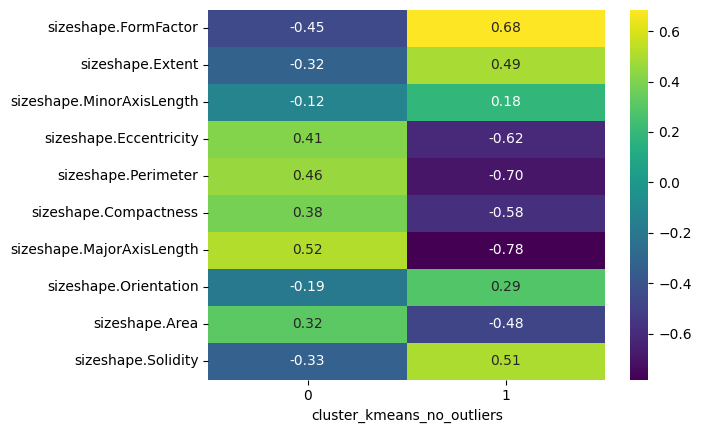

In [ ]:
SD_clean_no_outliers = SD_clean.copy()
SD_clean_no_outliers['cluster_kmeans_no_outliers'] = np.where(mask, labels_clean, -1)
SD_clean_no_outliers = SD_clean_no_outliers[SD_clean_no_outliers['cluster_kmeans_no_outliers'] != -1]

scaler = StandardScaler()
scaled = scaler.fit_transform(SD_clean_no_outliers[feats_CPmeasure])

SD_clean_no_outliers[feats_CPmeasure] = scaled

sns.heatmap(
    SD_clean_no_outliers[feats_CPmeasure + ['cluster_kmeans_no_outliers']]
    .groupby('cluster_kmeans_no_outliers')
    .mean()
    .T,
    cmap="viridis",
    annot=True,
    fmt=".2f"
)

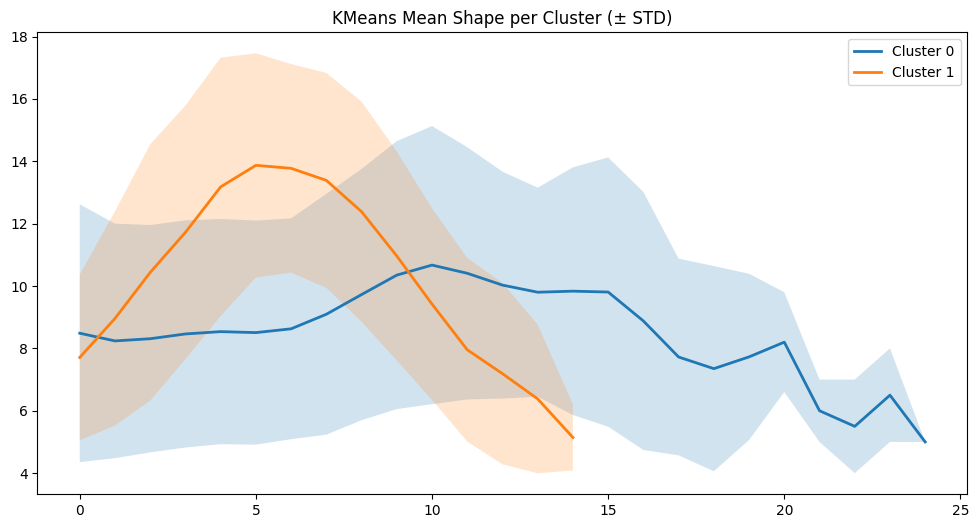

In [ ]:
X_kmeans = SD_clean_no_outliers["pseudotime_widths"].to_list()
labels_kmeans = SD_clean_no_outliers["cluster_kmeans_no_outliers"].values



plot_kmeans_mean_shapes(X_kmeans, labels_kmeans)

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# 1) Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 2) Optional: PCA to remove collinearity/noise
pca = PCA(n_components=2)  # or more components if needed
X_pca = pca.fit_transform(X_scaled)

# 3) Fit GMM
gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=42)
gmm.fit(X_pca)

# 4) Cluster labels (hard assignment)
labels_gmm = gmm.predict(X_pca)

# 5) Membership probabilities (soft assignment)
probs = gmm.predict_proba(X_pca)   # shape: (n_samples, 3)

# 6) Evaluate quality
sil = silhouette_score(X_pca, labels_gmm)
print("Silhouette GMM:", sil)

Silhouette GMM: 0.25117786752668586


In [12]:
def plot_metadata_heatmap(
    df,
    scaled_features,
    non_scaled_features,
    cluster_col,
    title="Morphology"
):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

    # non-scaled features
    non_scaled_data = (
        df[non_scaled_features + [cluster_col]]
        .groupby(cluster_col)
        .mean()
        .T
    )

    sns.heatmap(
        non_scaled_data,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        ax=axes[0]
    )
    axes[0].set_title(f"Non-scaled features per cluster ({cluster_col})")

    # scaled features
    scaled_data = (
        df[scaled_features + [cluster_col]]
        .groupby(cluster_col)
        .mean()
        .T
    )

    sns.heatmap(
        scaled_data,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        ax=axes[1]
    )
    axes[1].set_title(f"Scaled features per cluster ({cluster_col})")

    fig.suptitle(f"Mean morphology features per cluster in {cluster_col} ({title})")
    plt.tight_layout()
    plt.show()

KeyError: "['cluster_hdbscan'] not in index"

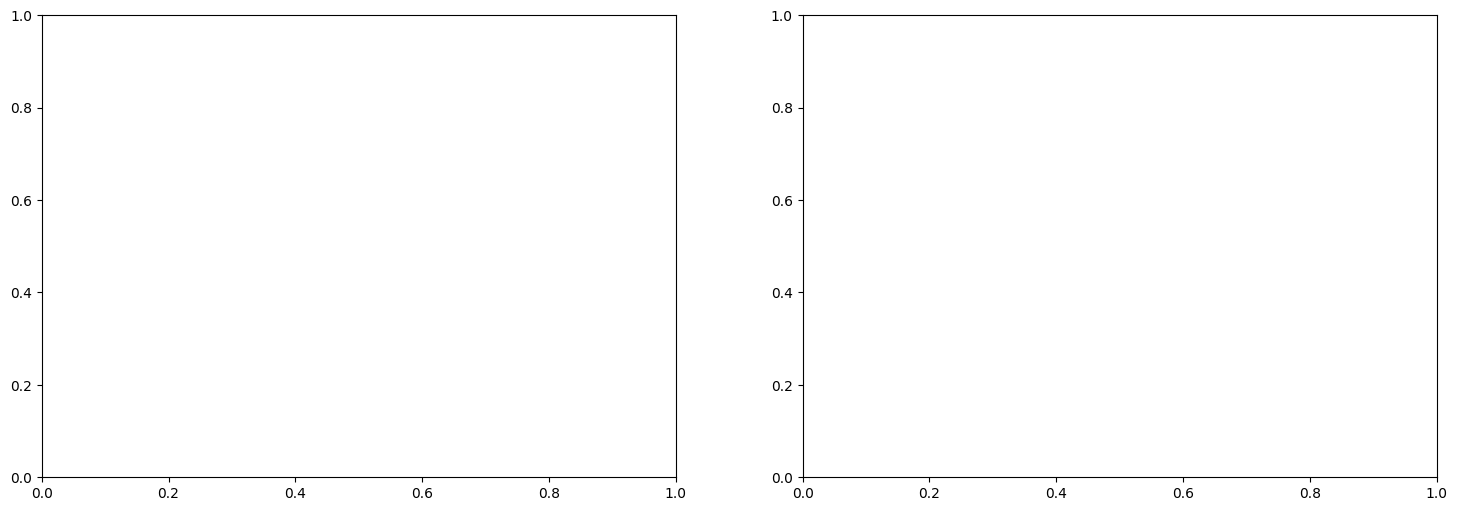

In [13]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df_identifyPrimaryObjects[feats])

feats_scaled = [f + "_scaled" for f in feats]   

df_identifyPrimaryObjects[feats_scaled] = scaled

plot_metadata_heatmap(
    df_identifyPrimaryObjects,
    feats_scaled,       # your list of scaled features
    feats,                # your list of non-scaled features
    "cluster_hdbscan",
    title="DAPI"
)

scaler = StandardScaler()
scaled = scaler.fit_transform(df_Phalloidin_segmented[feats])

df_Phalloidin_segmented[feats_scaled] = scaled

plot_metadata_heatmap(
    df_Phalloidin_segmented,
    feats_scaled,       # your list of scaled features
    feats,                # your list of non-scaled features
    "cluster_hdbscan",
    title="Phalloidin segmented"
)

scaler = StandardScaler()
scaled = scaler.fit_transform(df_YAP_segmented[feats])

df_YAP_segmented[feats_scaled] = scaled

plot_metadata_heatmap(
    df_YAP_segmented,
    feats_scaled,       # your list of scaled features
    feats,                # your list of non-scaled features
    "cluster_hdbscan",
    title="YAP segmented"
)

#counts per cluster
print("DAPI cluster counts:")
print(df_identifyPrimaryObjects["cluster_hdbscan"].value_counts())
print("\nPhalloidin segmented cluster counts:")
print(df_Phalloidin_segmented["cluster_hdbscan"].value_counts())
print("\nYAP segmented cluster counts:")
print(df_YAP_segmented["cluster_hdbscan"].value_counts())

In [14]:
cluster_map_kmeans = SD_clean[["Metadata_ObjNumber", "ObjectNumber", "cluster_kmeans"]]

df_identifyPrimaryObjects = add_cluster_to_cp(df_identifyPrimaryObjects, cluster_map_kmeans)
df_Phalloidin_segmented = add_cluster_to_cp(df_Phalloidin_segmented, cluster_map_kmeans)
df_YAP_segmented = add_cluster_to_cp(df_YAP_segmented, cluster_map_kmeans)

plot_metadata_heatmap(
    df_identifyPrimaryObjects,
    feats_scaled,       # your list of scaled features
    feats,                # your list of non-scaled features
    "cluster_kmeans",
    title="DAPI"
)

plot_metadata_heatmap(
    df_Phalloidin_segmented,
    feats_scaled,       # your list of scaled features
    feats,                # your list of non-scaled features
    "cluster_kmeans",
    title="Phalloidin segmented"
)

plot_metadata_heatmap(
    df_YAP_segmented,
    feats_scaled,       # your list of scaled features
    feats,                # your list of non-scaled features
    "cluster_kmeans",
    title="YAP segmented"
)



KeyError: "['cluster_kmeans'] not in index"

In [15]:
for c in SD_clean["cluster_hdbscan"].unique():
    d = SD_clean.loc[SD_clean["cluster_hdbscan"] == c, "pseudotime_center_bin"]
    print(c, len(d), np.std(d))

KeyError: 'cluster_hdbscan'

X_features shape: (667, 16)
X_pca shape: (667, 5)
Explained variance ratio: [0.41498574 0.34018128 0.07056464 0.04040446 0.03186516]
Explained variance sum: 0.8980012754690413


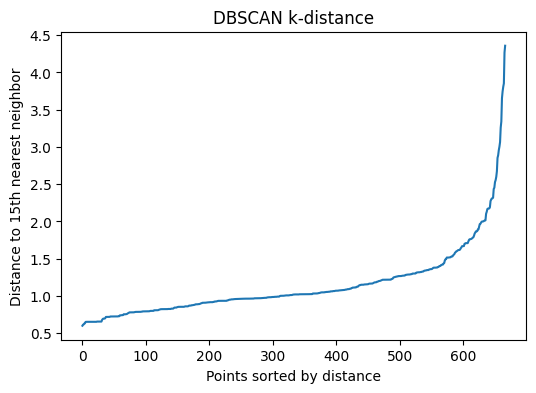

eps=1.2, silhouette_non_noise=nan, sizes={np.int64(-1): np.int64(81), np.int64(0): np.int64(586)}
eps=1.4, silhouette_non_noise=nan, sizes={np.int64(-1): np.int64(44), np.int64(0): np.int64(623)}
eps=1.6, silhouette_non_noise=nan, sizes={np.int64(-1): np.int64(24), np.int64(0): np.int64(643)}
eps=1.8, silhouette_non_noise=nan, sizes={np.int64(-1): np.int64(12), np.int64(0): np.int64(655)}
eps=2.0, silhouette_non_noise=nan, sizes={np.int64(-1): np.int64(11), np.int64(0): np.int64(656)}


,eps,silhouette_non_noise,sizes
0,1.2,NaN,"{-1: 81, 0: 586}"
1,1.4,NaN,"{-1: 44, 0: 623}"
2,1.6,NaN,"{-1: 24, 0: 643}"
3,1.8,NaN,"{-1: 12, 0: 655}"
4,2.0,NaN,"{-1: 11, 0: 656}"


k=2, silhouette=0.313, sizes={np.int64(0): np.int64(454), np.int64(1): np.int64(213)}
k=3, silhouette=0.311, sizes={np.int64(0): np.int64(255), np.int64(1): np.int64(213), np.int64(2): np.int64(199)}
k=4, silhouette=0.326, sizes={np.int64(0): np.int64(213), np.int64(1): np.int64(163), np.int64(2): np.int64(199), np.int64(3): np.int64(92)}
k=5, silhouette=0.315, sizes={np.int64(0): np.int64(163), np.int64(1): np.int64(119), np.int64(2): np.int64(199), np.int64(3): np.int64(92), np.int64(4): np.int64(94)}
k=6, silhouette=0.296, sizes={np.int64(0): np.int64(199), np.int64(1): np.int64(119), np.int64(2): np.int64(98), np.int64(3): np.int64(92), np.int64(4): np.int64(94), np.int64(5): np.int64(65)}


,k,silhouette,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5
0,2,0.313087,454,213,0.0,0.0,0.0,0.0
1,3,0.311485,255,213,199.0,0.0,0.0,0.0
2,4,0.325808,213,163,199.0,92.0,0.0,0.0
3,5,0.315495,163,119,199.0,92.0,94.0,0.0
4,6,0.295924,199,119,98.0,92.0,94.0,65.0


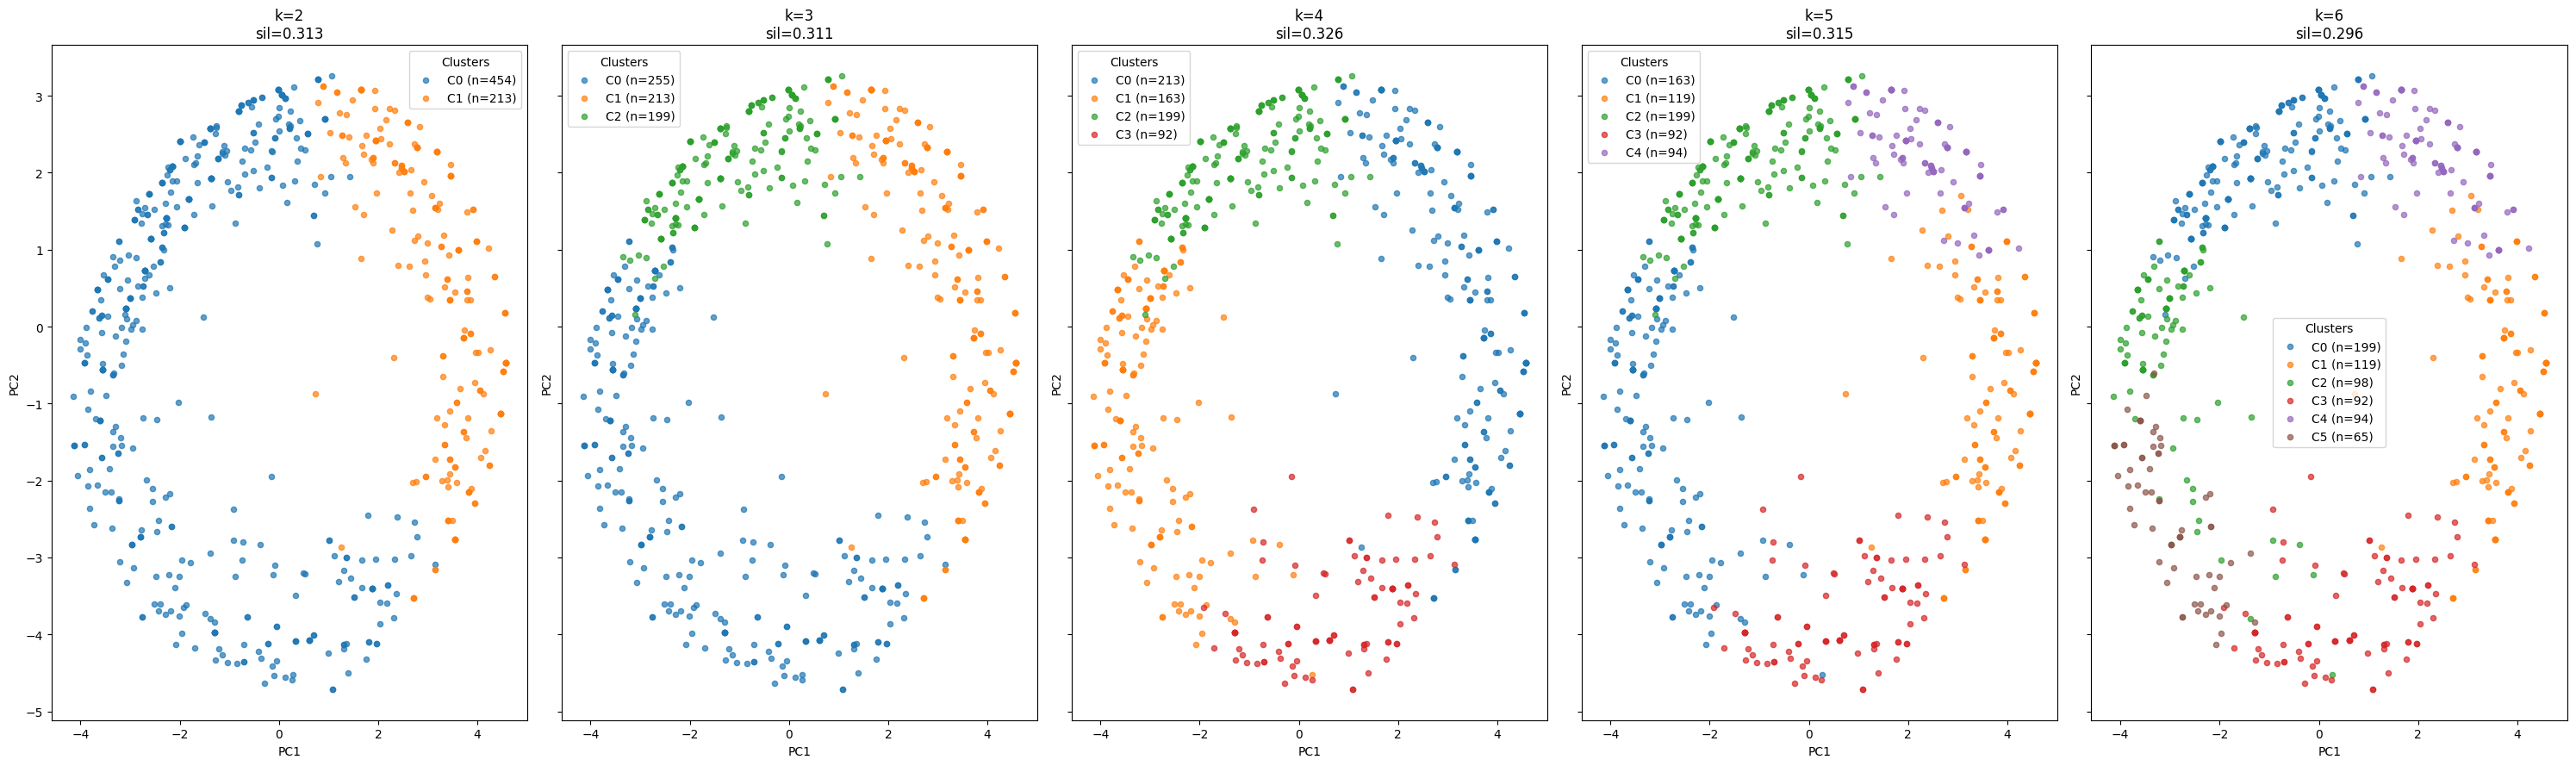

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score


# ============================================================
# 1. Build fixed-length feature matrix from pseudotime_widths
# ============================================================

X_series = SD_clean["pseudotime_widths"].to_list()
lengths = np.array([len(ts) for ts in X_series], dtype=int)

def resample_ts_raw(ts, target_len):
    ts = np.asarray(ts, dtype=float)
    x_old = np.linspace(0, 1, len(ts))
    x_new = np.linspace(0, 1, target_len)
    return np.interp(x_new, x_old, ts)

target_len = int(np.median(lengths))

X_shape = np.vstack([
    resample_ts_raw(ts, target_len) for ts in X_series
])

# optional extra feature: original trajectory length
orig_len = lengths.astype(float).reshape(-1, 1)

# final feature matrix
X_features = np.hstack([X_shape, orig_len])


# ============================================================
# 2. Scale and PCA
# ============================================================

X_scaled = StandardScaler().fit_transform(X_features)

# one deterministic PCA for clustering
n_pcs_cluster = 5
pca = PCA(n_components=n_pcs_cluster, svd_solver="full")
X_pca = pca.fit_transform(X_scaled)

# for plotting: use first 2 PCs from the SAME PCA
X_plot = X_pca[:, :2]

print("X_features shape:", X_features.shape)
print("X_pca shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Explained variance sum:", pca.explained_variance_ratio_.sum())


# ============================================================
# 3. DBSCAN exploration
# ============================================================

min_samples = 15

nbrs = NearestNeighbors(n_neighbors=min_samples)
nbrs.fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
kdist = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(kdist)
plt.title("DBSCAN k-distance")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.show()

dbscan_results = []

for eps in [1.2, 1.4, 1.6, 1.8, 2.0]:
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_pca)
    unique, counts = np.unique(labels, return_counts=True)
    sizes = dict(zip(unique, counts))

    mask = labels != -1
    if len(np.unique(labels[mask])) >= 2:
        sil = silhouette_score(X_pca[mask], labels[mask])
    else:
        sil = np.nan

    dbscan_results.append({
        "eps": eps,
        "silhouette_non_noise": sil,
        "sizes": sizes
    })

    print(f"eps={eps}, silhouette_non_noise={sil}, sizes={sizes}")

dbscan_summary = pd.DataFrame(dbscan_results)
display(dbscan_summary)


# ============================================================
# 4. Agglomerative clustering evaluation
# ============================================================

ks = [2,3,4, 5,6 ]
results = []

for k in ks:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X_pca)

    sil = silhouette_score(X_pca, labels)
    unique, counts = np.unique(labels, return_counts=True)
    sizes = dict(zip(unique, counts))

    colname = f"cluster_agg_k{k}"
    SD_clean[colname] = labels

    results.append({
        "k": k,
        "labels": labels,
        "silhouette": sil,
        "sizes": sizes,
        "colname": colname
    })

    print(f"k={k}, silhouette={sil:.3f}, sizes={sizes}")

agg_summary = pd.DataFrame([
    {
        "k": r["k"],
        "silhouette": r["silhouette"],
        **{f"cluster_{c}": n for c, n in r["sizes"].items()}
    }
    for r in results
]).fillna(0)

display(agg_summary)


# ============================================================
# 5. PCA scatter plots for k=2,3,4,5,6
# ============================================================

fig, axes = plt.subplots(1, len(ks), figsize=(6 * len(ks), 9), sharex=True, sharey=True)

if len(ks) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    labels = r["labels"]

    for c in np.unique(labels):
        idx = labels == c
        n_nuclei = np.sum(idx)  # number of nuclei in this cluster

        ax.scatter(
            X_plot[idx, 0],
            X_plot[idx, 1],
            s=20,
            alpha=0.7,
            label=f"C{c} (n={n_nuclei})"
        )

    ax.set_title(f"k={r['k']}\nsil={r['silhouette']:.3f}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(title="Clusters")

plt.tight_layout()
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plots_on_background(
    img_path,
    df,
    value_col="pseudotime_center_bin",
    cluster_col="cluster_agg_k5",
    m=2,
    rotate=True,
    scale_values=True,
    buffer_ratio=20/140,
    jitter_frac=0.14,
    x_squeeze=0.35,   # <--- smaller = tighter x spread
    point_size=50,
    seed=0
):
    # --- load image ---
    img = plt.imread(img_path)

    if rotate:
        img = np.rot90(img)

    # ensure RGBA
    if img.ndim == 3 and img.shape[2] == 3:
        alpha = np.ones((img.shape[0], img.shape[1], 1))
        img = np.concatenate([img, alpha], axis=2)

    # recolor near-white background
    if img.ndim == 3 and img.shape[2] >= 3:
        mask = (img[:, :, :3] > 0.98).all(axis=2)
        img[mask] = [230/255, 255/255, 221/255, 1]

    H, W = img.shape[:2]
    y_max = H / m

    y_start = y_max * buffer_ratio
    y_end = y_max * (1 - buffer_ratio)
    plot_height = y_end - y_start

    # cluster list
    clusters = sorted(df[cluster_col].dropna().unique())
    n_clusters = len(clusters)

    fig, axes = plt.subplots(
        1,
        n_clusters,
        figsize=(3.2 * n_clusters, 5),
        sharey=True
    )

    if n_clusters == 1:
        axes = [axes]

    # global scaling for value_col if requested
    vals_all = df[value_col].dropna().to_numpy()
    vmin = np.min(vals_all)
    vmax = np.max(vals_all)

    for i, (ax, cluster) in enumerate(zip(axes, clusters)):
        ax.imshow(
            img,
            extent=[0, W, 0, y_max],
            origin="upper",
            aspect="auto"
        )

        data = (
            df.loc[df[cluster_col] == cluster, value_col]
            .dropna()
            .to_numpy()
        )

        if len(data) == 0:
            ax.set_title(f"{cluster_col}: {cluster}\n(no data)")
            ax.set_xlim(0, W)
            ax.set_ylim(0, y_max)
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        # map data to drawable vertical range
        if scale_values:
            if vmax > vmin:
                y = y_start + (data - vmin) / (vmax - vmin) * plot_height
            else:
                y = np.full_like(data, y_start + plot_height / 2, dtype=float)
        else:
            y = y_start + data

        rng = np.random.default_rng(seed + i)

        # squeezed horizontal jitter around center
        x = W / 3.5 + rng.normal(0, W * jitter_frac * x_squeeze, size=len(data))

        ax.scatter(
            x,
            y,
            s=point_size,
            alpha=0.6
        )

        ax.boxplot(
            y,
            positions=[W / 3.5],
            widths=W * 0.2 * x_squeeze,  # optional: also squeeze box width
            vert=True,
            patch_artist=True,
            boxprops=dict(facecolor="white", alpha=0.6),
            medianprops=dict(color="red", linewidth=2),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black")
        )

        ax.set_xlim(0, W)
        ax.set_ylim(0, y_max)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines["left"].set_visible(False)
        ax.set_ylabel("")
        ax.set_title(f"{cluster_col}: {int(cluster)}\nN={len(data)}")

    plt.tight_layout()
    plt.show()

In [18]:
df_save = SD_clean.drop(columns=["cluster_agg_k3", "cluster_agg_k4", "cluster_agg_k5", "cluster_agg_k6"], errors="ignore").copy()
df_save.to_csv("datasets/combined_clustered_data_1476_k2.csv", index=False)

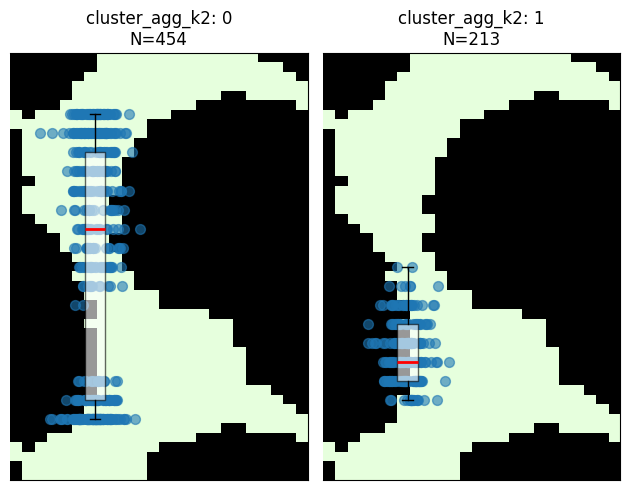

In [113]:
plots_on_background(
    img_path=r"res\period_corridor_7_2026-03-20_13-25-56.png",
    df=SD_clean,
    value_col="pseudotime_center_bin",
    cluster_col="cluster_agg_k2"
)

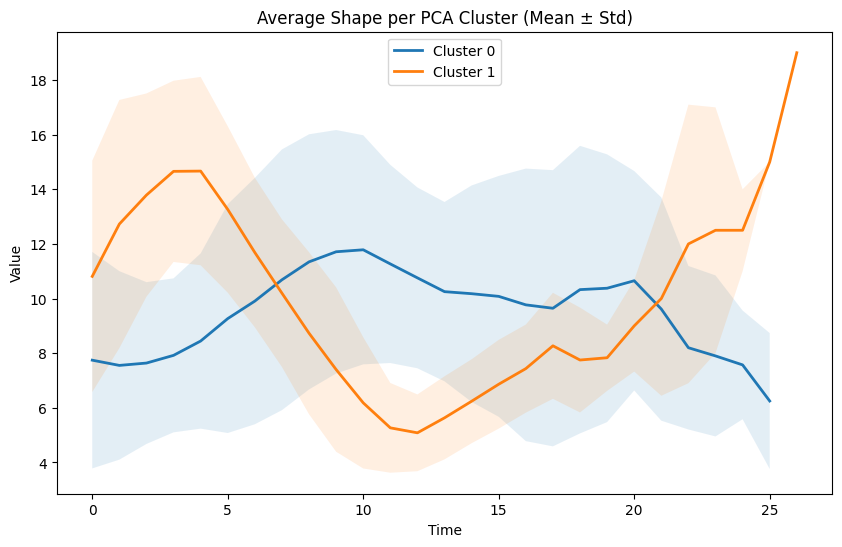

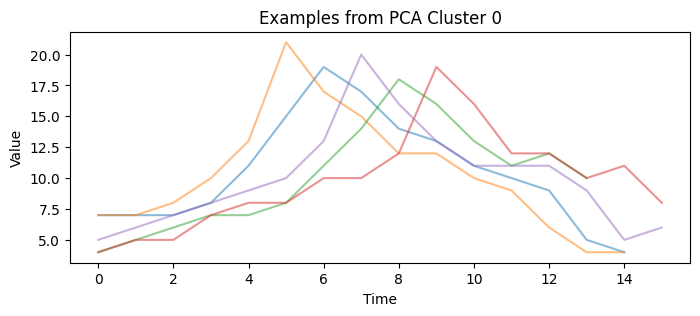

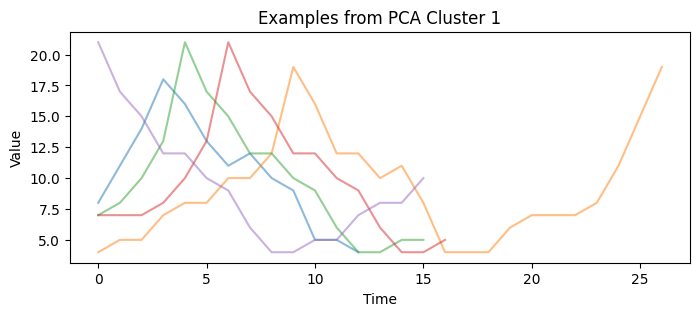

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import random

# use your PCA/agglomerative k=2 labels
labels_pca = SD_clean["cluster_agg_k2"].to_numpy()

# original variable-length trajectories
X = SD_clean["pseudotime_widths"].to_list()

# --------------------------------------------------
# Mean ± std trajectory per PCA cluster
# --------------------------------------------------
plt.figure(figsize=(10, 6))

for lab in np.unique(labels_pca):
    idx = labels_pca == lab
    cluster_ts = [np.asarray(X[i], dtype=float) for i in np.where(idx)[0]]

    max_len = max(len(ts) for ts in cluster_ts)
    aligned = [
        np.pad(ts, (0, max_len - len(ts)), mode="constant", constant_values=np.nan)
        for ts in cluster_ts
    ]
    aligned = np.vstack(aligned)

    mean_ts = np.nanmean(aligned, axis=0)
    std_ts = np.nanstd(aligned, axis=0)

    t = np.arange(max_len)

    plt.plot(t, mean_ts, label=f"Cluster {lab}", linewidth=2)
    plt.fill_between(t, mean_ts - std_ts, mean_ts + std_ts, alpha=0.12)

plt.legend()
plt.title("Average Shape per PCA Cluster (Mean ± Std)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()


# --------------------------------------------------
# Example trajectories per PCA cluster
# --------------------------------------------------
random.seed(0)

for lab in np.unique(labels_pca):
    idx = np.where(labels_pca == lab)[0]
    sample_idxs = random.sample(list(idx), min(5, len(idx)))

    plt.figure(figsize=(8, 3))
    for i in sample_idxs:
        plt.plot(X[i], alpha=0.5)
    plt.title(f"Examples from PCA Cluster {lab}")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.show()

In [102]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile


def read_image(path):
    return tifffile.imread(path)


def to_2d(img):
    img = np.asarray(img)
    if img.ndim == 2:
        return img
    if img.ndim == 3:
        if img.shape[0] == 1:
            return img[0]
        if img.shape[-1] == 1:
            return img[..., 0]
        return img[0] if img.shape[0] <= 4 else img[..., 0]
    raise ValueError(f"Unsupported image shape: {img.shape}")


def normalize_percentile(img, pmin=1, pmax=99):
    img = np.asarray(img, dtype=np.float32)
    lo = np.percentile(img, pmin)
    hi = np.percentile(img, pmax)
    if hi <= lo:
        return np.zeros_like(img, dtype=np.float32)
    return np.clip((img - lo) / (hi - lo), 0, 1)


def scale_dapi_fixed(dapi, fixed_max=160.0):
    """
    No percentile normalization.
    Just divide by one fixed intensity ceiling for all images.
    Adjust fixed_max if needed.
    """
    dapi = np.asarray(dapi, dtype=np.float32)
    if fixed_max <= 0:
        raise ValueError("fixed_max must be > 0")
    return np.clip(dapi / fixed_max, 0, 1)


def make_overlay_fixed_dapi(
    bg,
    dapi,
    bf_weight=0.35,
    dapi_gain=4.0,
    invert_bf=True,
    dapi_fixed_max=160.0
):
    # keep background normalization
    bg_norm = normalize_percentile(bg, 1, 99)

    if invert_bf:
        bg_norm = 1.0 - bg_norm

    # no percentile normalization for DAPI
    dapi_disp = scale_dapi_fixed(dapi, fixed_max=dapi_fixed_max)
    dapi_enh = np.clip(dapi_disp * dapi_gain, 0, 1)

    rgb = np.zeros((*bg.shape, 3), dtype=np.float32)
    rgb[..., 0] = bg_norm * bf_weight
    rgb[..., 1] = bg_norm * bf_weight
    rgb[..., 2] = bg_norm * bf_weight

    rgb[..., 2] += dapi_enh
    rgb[..., 1] += dapi_enh * 0.15
    rgb[..., 0] += dapi_enh * 0.05
    rgb = np.clip(rgb, 0, 1)

    return rgb, dapi_disp, dapi_enh


def crop_from_signal(img, signal, thr=0.15, pad=25):
    mask = signal > thr
    ys, xs = np.where(mask)

    if len(xs) == 0:
        return img

    y0 = max(int(ys.min()) - pad, 0)
    y1 = min(int(ys.max()) + pad + 1, img.shape[0])
    x0 = max(int(xs.min()) - pad, 0)
    x1 = min(int(xs.max()) + pad + 1, img.shape[1])

    return img[y0:y1, x0:x1]


def save_cluster_debug_pages(
    df,
    cluster_id,
    cluster_col="cluster_agg_k2",
    bg_col="path_background",
    dapi_col="path_dapi",
    out_dir=r"C:\Users\20212358\Desktop\pseudotime_github\1476_cluster_debug_pages_k2",
    rows_per_page=10,
    bf_weight=0.35,
    dapi_gain=4.0,
    invert_bf=True,
    dapi_fixed_max=160.0,
    crop_thr=0.15,
    crop_pad=25,
    sort_by_index=True
):
    out_dir = Path(out_dir)
    cluster_dir = out_dir / f"{cluster_col}_cluster_{int(cluster_id)}"
    cluster_dir.mkdir(parents=True, exist_ok=True)

    sub = df[df[cluster_col] == cluster_id].copy()
    if sort_by_index:
        sub = sub.sort_index()

    n = len(sub)
    n_pages = math.ceil(n / rows_per_page)

    print(f"Saving {n} rows as {n_pages} pages for cluster {cluster_id}")

    manifest_rows = []

    for page in range(n_pages):
        start = page * rows_per_page
        stop = min((page + 1) * rows_per_page, n)
        batch = sub.iloc[start:stop]

        fig, axes = plt.subplots(
            nrows=rows_per_page,
            ncols=5,
            figsize=(18, rows_per_page * 3.2)
        )

        # if only one row, axes needs reshaping
        if rows_per_page == 1:
            axes = np.array([axes])

        # hide everything first
        for ax_row in axes:
            for ax in ax_row:
                ax.axis("off")

        for r, (idx, row) in enumerate(batch.iterrows()):
            bg = to_2d(read_image(row[bg_col]))
            dapi = to_2d(read_image(row[dapi_col]))

            if bg.shape != dapi.shape:
                raise ValueError(
                    f"Shape mismatch at row {idx}: background {bg.shape}, dapi {dapi.shape}"
                )

            overlay, dapi_disp, dapi_enh = make_overlay_fixed_dapi(
                bg=bg,
                dapi=dapi,
                bf_weight=bf_weight,
                dapi_gain=dapi_gain,
                invert_bf=invert_bf,
                dapi_fixed_max=dapi_fixed_max
            )

            cropped_overlay = crop_from_signal(
                overlay, dapi_enh, thr=crop_thr, pad=crop_pad
            )

            ax0, ax1, ax2, ax3, ax4 = axes[r]

            ax0.imshow(bg, cmap="gray")
            ax1.imshow(dapi, cmap="gray")
            ax2.imshow(dapi_disp, cmap="gray")
            ax3.imshow(overlay)
            ax4.imshow(cropped_overlay)

            for ax in [ax0, ax1, ax2, ax3, ax4]:
                ax.axis("off")

            if r == 0:
                ax0.set_title("background", fontsize=12)
                ax1.set_title("DAPI raw", fontsize=12)
                ax2.set_title("DAPI fixed-scale", fontsize=12)
                ax3.set_title("full overlay", fontsize=12)
                ax4.set_title("cropped overlay", fontsize=12)

            meta_obj = int(row["Metadata_ObjNumber"]) if "Metadata_ObjNumber" in row else -1
            obj_num = int(row["ObjectNumber"]) if "ObjectNumber" in row else -1

            ax0.set_ylabel(
                f"row {idx}\nimg {meta_obj}\nobj {obj_num}",
                rotation=0,
                ha="right",
                va="center",
                fontsize=10,
                labelpad=35
            )

            manifest_rows.append({
                "page": page + 1,
                "df_index": idx,
                "cluster": int(cluster_id),
                "Metadata_ObjNumber": meta_obj,
                "ObjectNumber": obj_num,
                "path_background": row[bg_col],
                "path_dapi": row[dapi_col]
            })

        fig.suptitle(
            f"{cluster_col} = {cluster_id} | page {page + 1}/{n_pages} | "
            f"DAPI fixed scale max={dapi_fixed_max}",
            fontsize=14
        )
        plt.tight_layout()

        out_path = cluster_dir / f"page_{page + 1:03d}.png"
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close(fig)

    manifest = pd.DataFrame(manifest_rows)
    manifest.to_csv(cluster_dir / "manifest.csv", index=False)
    print(f"Done. Saved to: {cluster_dir}")

In [103]:
for cl in sorted(SD_clean["cluster_agg_k2"].dropna().astype(int).unique()):
    save_cluster_debug_pages(
        df=SD_clean,
        cluster_id=cl,
        cluster_col="cluster_agg_k2",
        bg_col="path_background",
        dapi_col="path_dapi",
        out_dir=r"C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\res\1476_cluster_debug_pages_k2",
        rows_per_page=10,
        bf_weight=0.35,
        dapi_gain=4.0,
        invert_bf=True,
        dapi_fixed_max=160.0,
        crop_thr=0.15,
        crop_pad=25
    )

Saving 454 rows as 46 pages for cluster 0
Done. Saved to: C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\res\1476_cluster_debug_pages_k2\cluster_agg_k2_cluster_0
Saving 213 rows as 22 pages for cluster 1
Done. Saved to: C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\res\1476_cluster_debug_pages_k2\cluster_agg_k2_cluster_1


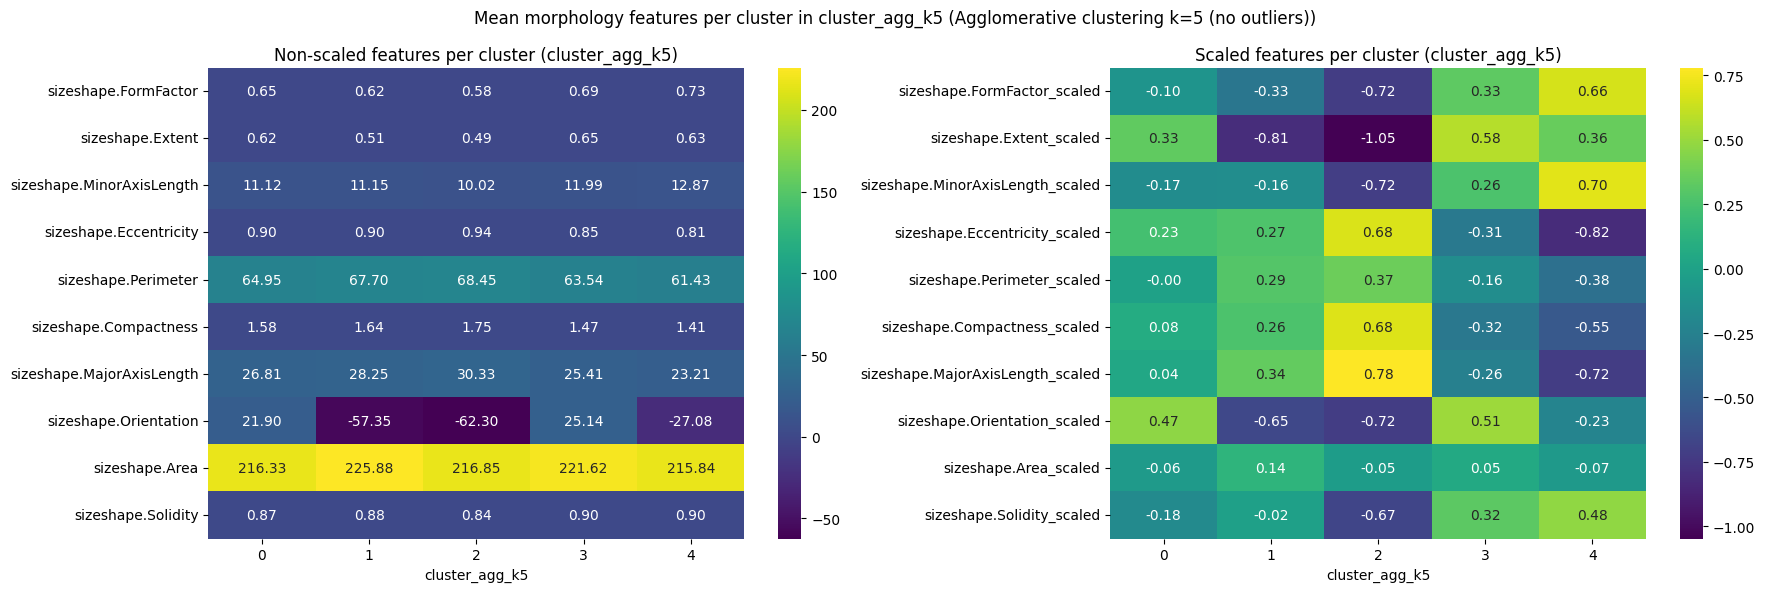

In [89]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------------------------------
# Build a plotting dataframe for the no-outlier subset
# using the agglomerative k=5 labels
# --------------------------------------------------
cluster_col = "cluster_agg_k5"

# use the original, non-scaled morphology values
# but only for rows kept in SD_clean_no_outliers
morph_plot_df = SD_clean.loc[SD_clean_no_outliers.index, feats_CPmeasure].copy()

# add the agglomerative k=5 labels
morph_plot_df[cluster_col] = SD_clean_no_outliers[cluster_col].values

# create scaled morphology columns for this subset
scaler = StandardScaler()
feats_CPmeasure_scaled_no_outliers = [f + "_scaled" for f in feats_CPmeasure]
morph_plot_df[feats_CPmeasure_scaled_no_outliers] = scaler.fit_transform(
    morph_plot_df[feats_CPmeasure]
)

def plot_metadata_heatmap(
    df,
    scaled_features,
    non_scaled_features,
    cluster_col,
    title="Morphology"
):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

    # non-scaled features
    non_scaled_data = (
        df[non_scaled_features + [cluster_col]]
        .groupby(cluster_col)
        .mean()
        .T
    )

    sns.heatmap(
        non_scaled_data,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        ax=axes[0]
    )
    axes[0].set_title(f"Non-scaled features per cluster ({cluster_col})")

    # scaled features
    scaled_data = (
        df[scaled_features + [cluster_col]]
        .groupby(cluster_col)
        .mean()
        .T
    )

    sns.heatmap(
        scaled_data,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        ax=axes[1]
    )
    axes[1].set_title(f"Scaled features per cluster ({cluster_col})")

    fig.suptitle(f"Mean morphology features per cluster in {cluster_col} ({title})")
    plt.tight_layout()
    plt.show()

plot_metadata_heatmap(
    morph_plot_df,
    feats_CPmeasure_scaled_no_outliers,
    feats_CPmeasure,
    cluster_col,
    title="Agglomerative clustering k=5 (no outliers)"
)

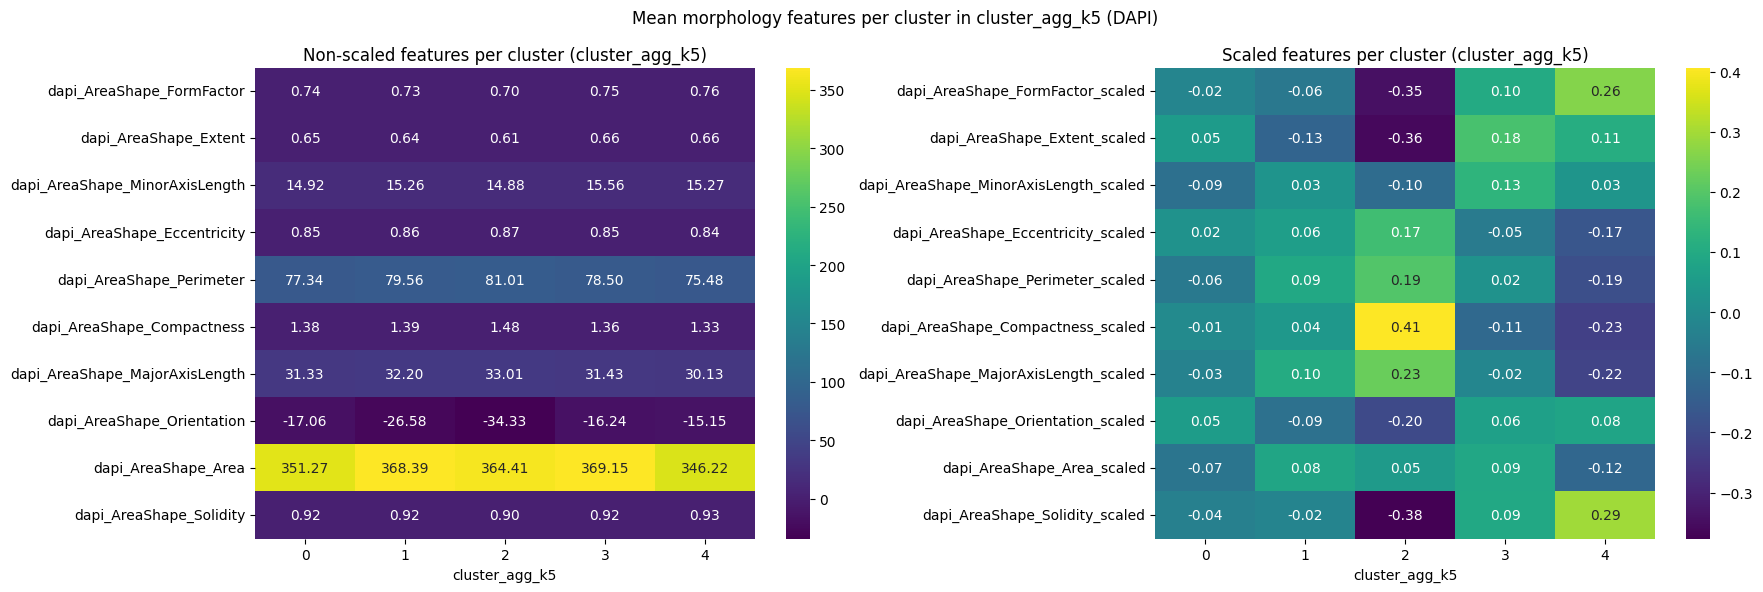


DAPI cluster counts:
cluster_agg_k5
0    156
1     89
2     81
3    126
4     93
Name: count, dtype: int64


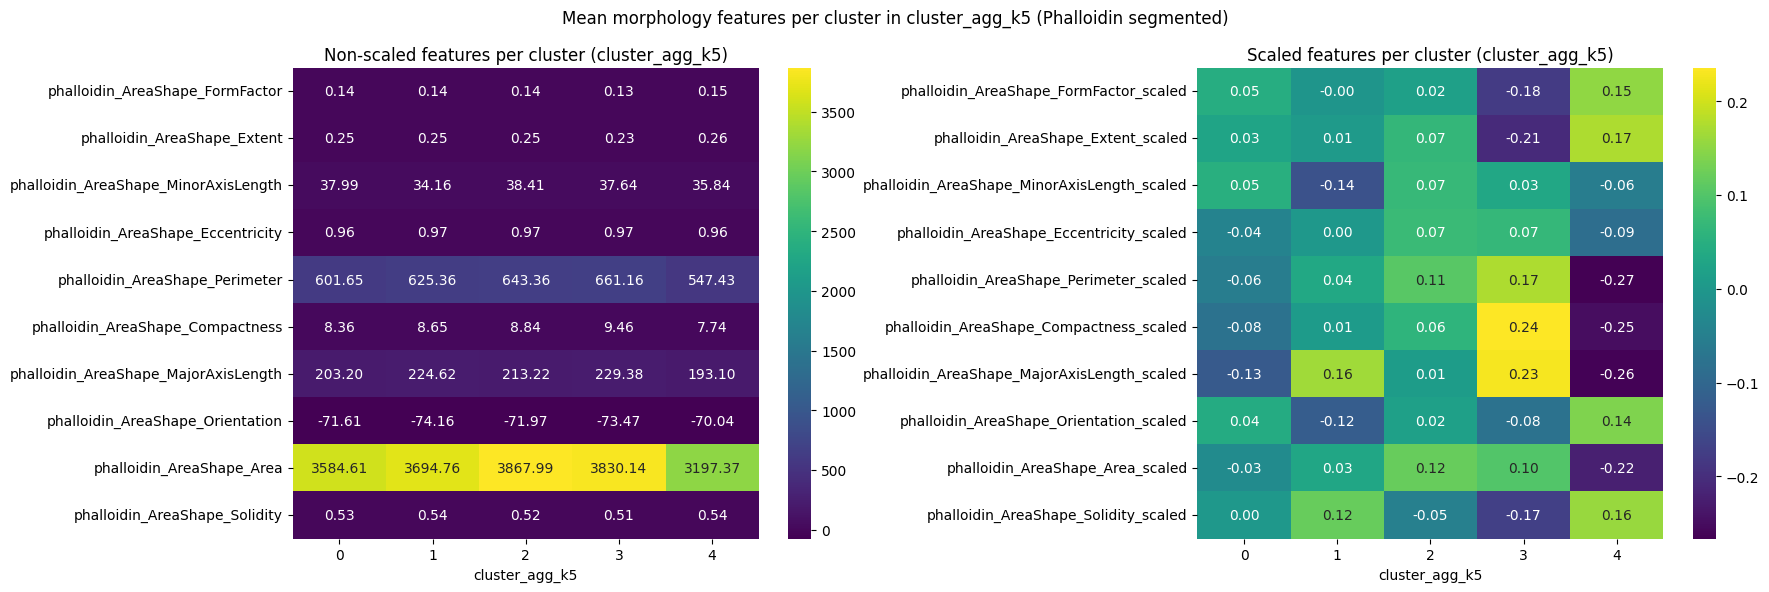


Phalloidin segmented cluster counts:
cluster_agg_k5
0    156
1     89
2     81
3    126
4     93
Name: count, dtype: int64


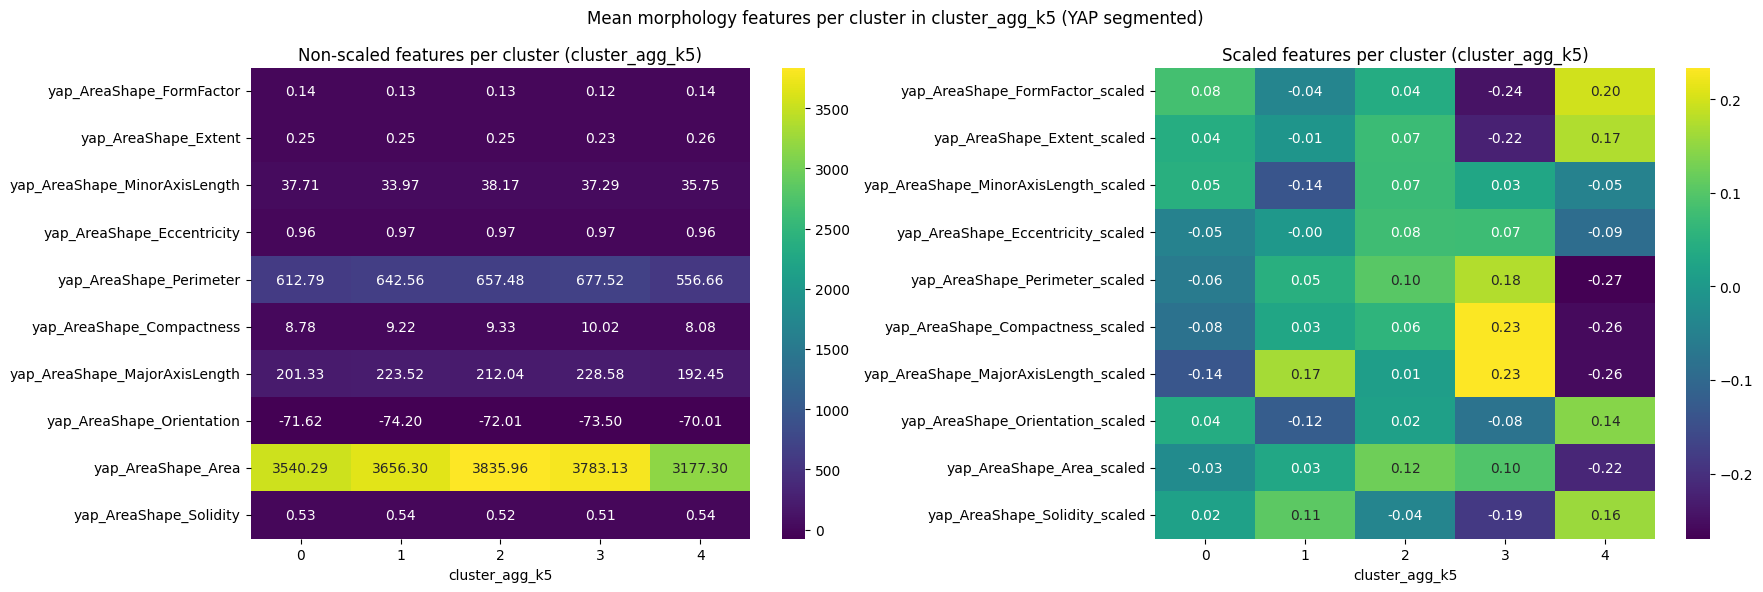


YAP segmented cluster counts:
cluster_agg_k5
0    156
1     89
2     81
3    126
4     93
Name: count, dtype: int64


In [90]:
from sklearn.preprocessing import StandardScaler

cluster_col = "cluster_agg_k5"

feats = [
    'AreaShape_FormFactor',
    'AreaShape_Extent',
    'AreaShape_MinorAxisLength',
    'AreaShape_Eccentricity',
    'AreaShape_Perimeter',
    'AreaShape_Compactness',
    'AreaShape_MajorAxisLength',
    'AreaShape_Orientation',
    'AreaShape_Area',
    'AreaShape_Solidity',
]

def plot_channel_heatmap(df, prefix, feats, cluster_col, title):
    # build prefixed feature names, e.g. dapi_AreaShape_FormFactor
    non_scaled_feats = [f"{prefix}_{f}" for f in feats if f"{prefix}_{f}" in df.columns]

    if len(non_scaled_feats) == 0:
        print(f"No features found for prefix '{prefix}'")
        return None

    # keep only rows with complete data for this channel
    plot_df = df[non_scaled_feats + [cluster_col]].dropna().copy()

    # scale channel-specific features
    scaler = StandardScaler()
    scaled_feats = [f"{f}_scaled" for f in non_scaled_feats]
    plot_df[scaled_feats] = scaler.fit_transform(plot_df[non_scaled_feats])

    # IMPORTANT:
    # your current plot_metadata_heatmap function expects:
    # (df, scaled_features, non_scaled_features, cluster_col, title)
    plot_metadata_heatmap(
        plot_df,
        scaled_feats,
        non_scaled_feats,
        cluster_col,
        title=title
    )

    print(f"\n{title} cluster counts:")
    print(plot_df[cluster_col].value_counts().sort_index())

    return plot_df


# DAPI-based segmentation features
df_dapi_plot = plot_channel_heatmap(
    SD_clean_no_outliers,
    "dapi",
    feats,
    cluster_col,
    title="DAPI"
)

# Phalloidin-segmented features
df_phalloidin_plot = plot_channel_heatmap(
    SD_clean_no_outliers,
    "phalloidin",
    feats,
    cluster_col,
    title="Phalloidin segmented"
)

# YAP-segmented features
df_yap_plot = plot_channel_heatmap(
    SD_clean_no_outliers,
    "yap",
    feats,
    cluster_col,
    title="YAP segmented"
)


DAPI — top 10 most variable intensity metrics:
dapi_Intensity_IntegratedIntensity_DNA            54.414663
dapi_Location_MaxIntensity_X_Phalloidin           35.290547
dapi_Location_MaxIntensity_X_YAP                  35.074992
dapi_Location_MaxIntensity_X_DNA                  34.376353
dapi_Location_CenterMassIntensity_X_YAP           33.834614
dapi_Location_CenterMassIntensity_X_DNA           33.812639
dapi_Location_CenterMassIntensity_X_Phalloidin    33.791697
dapi_Intensity_IntegratedIntensity_Phalloidin     26.034619
dapi_Intensity_IntegratedIntensity_YAP            19.317351
dapi_Location_MaxIntensity_Y_Phalloidin           13.305631
dtype: float64


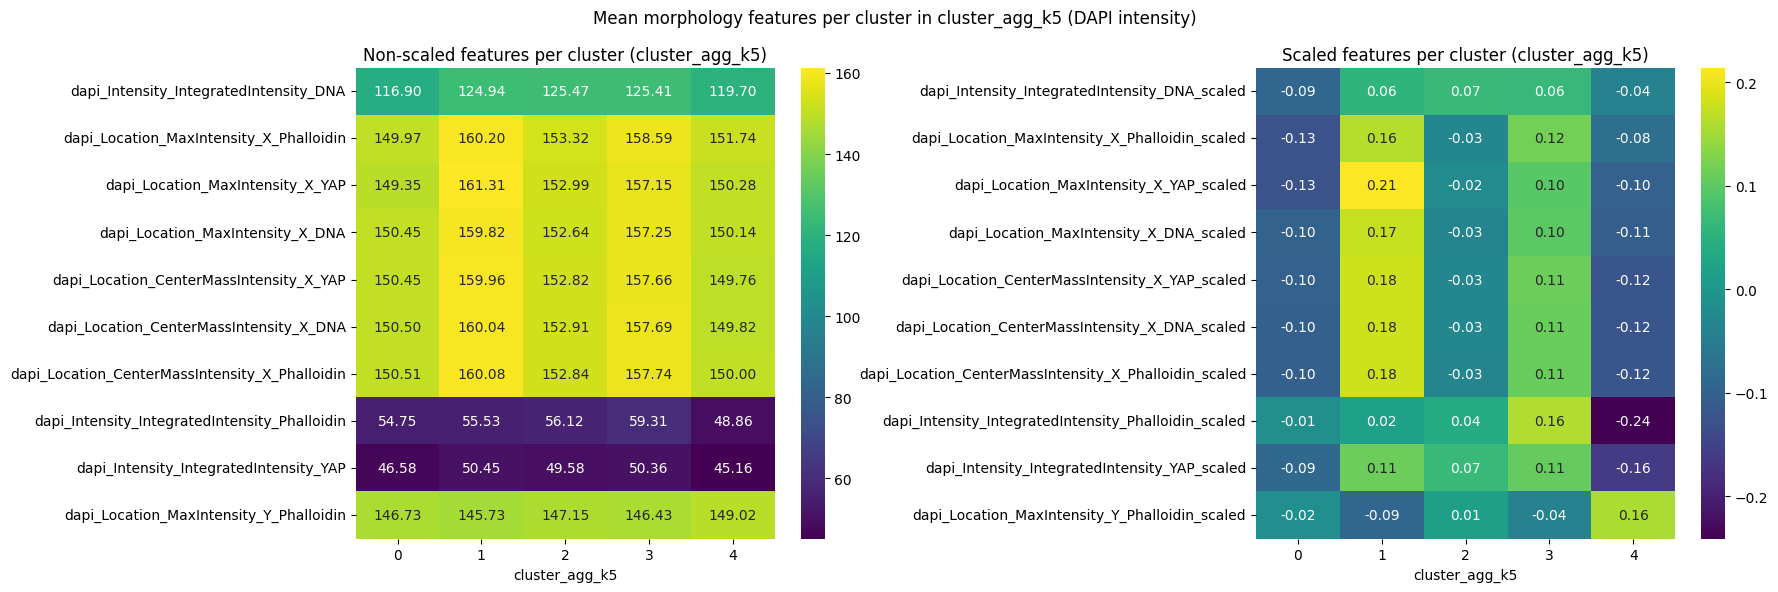


DAPI cluster counts:
cluster_agg_k5
0    156
1     89
2     81
3    126
4     93
Name: count, dtype: int64

Phalloidin segmented — top 10 most variable intensity metrics:
phalloidin_Intensity_IntegratedIntensity_Phalloidin     303.903318
phalloidin_Intensity_IntegratedIntensity_DNA            151.826918
phalloidin_Intensity_IntegratedIntensity_YAP            146.145363
phalloidin_Location_MaxIntensity_X_Phalloidin            65.732823
phalloidin_Location_MaxIntensity_X_YAP                   36.122607
phalloidin_Location_MaxIntensity_X_DNA                   34.348197
phalloidin_Location_MaxIntensity_Y_Phalloidin            21.514875
phalloidin_Location_CenterMassIntensity_X_DNA            17.188450
phalloidin_Location_CenterMassIntensity_X_Phalloidin     14.896991
phalloidin_Intensity_IntegratedIntensityEdge_DNA         14.740776
dtype: float64


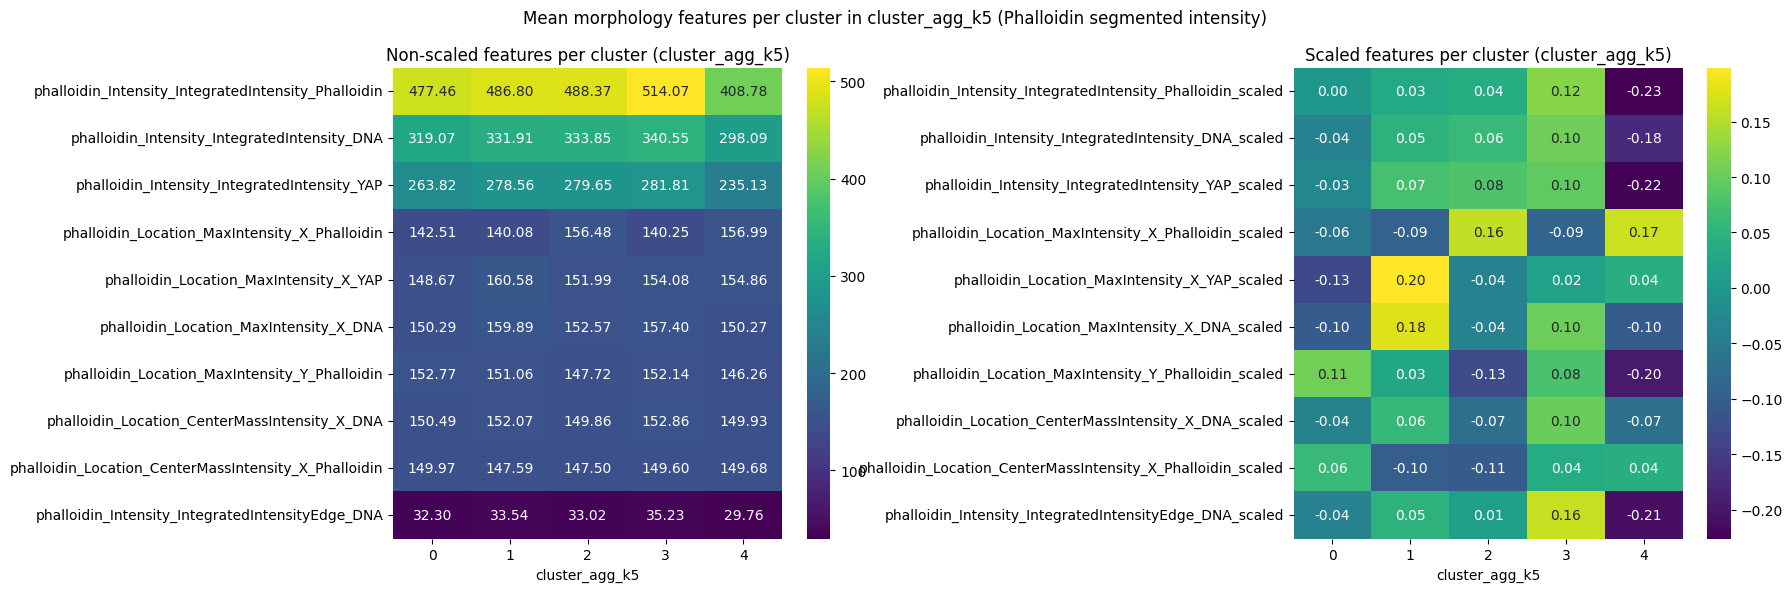


Phalloidin segmented cluster counts:
cluster_agg_k5
0    156
1     89
2     81
3    126
4     93
Name: count, dtype: int64

YAP segmented — top 10 most variable intensity metrics:
yap_Intensity_IntegratedIntensity_Phalloidin        301.937676
yap_Intensity_IntegratedIntensity_DNA               150.988749
yap_Intensity_IntegratedIntensity_YAP               145.540079
yap_Location_MaxIntensity_X_Phalloidin               65.817490
yap_Location_MaxIntensity_X_YAP                      35.979866
yap_Location_MaxIntensity_X_DNA                      34.405448
yap_Location_MaxIntensity_Y_Phalloidin               21.392872
yap_Location_CenterMassIntensity_X_DNA               17.251264
yap_Intensity_IntegratedIntensityEdge_Phalloidin     15.721093
yap_Intensity_IntegratedIntensityEdge_DNA            15.535744
dtype: float64


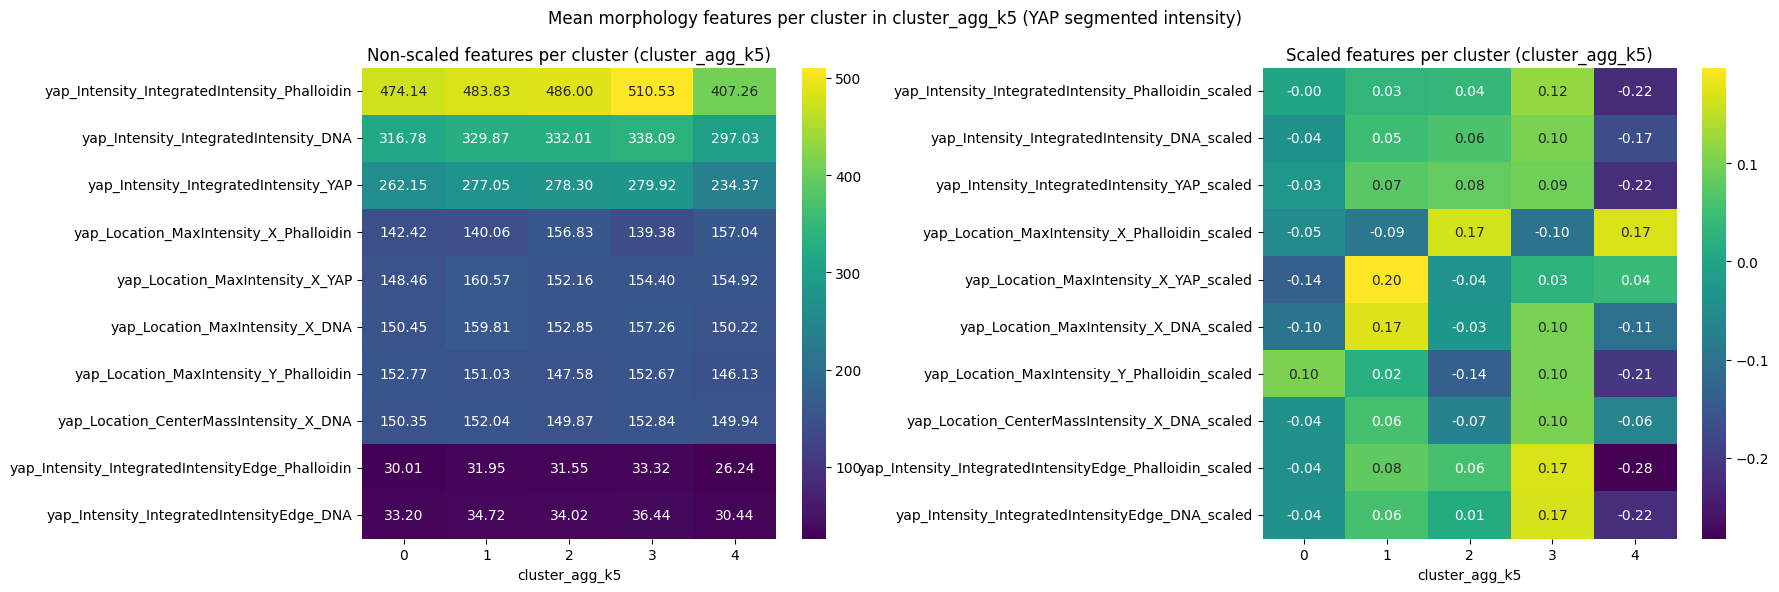


YAP segmented cluster counts:
cluster_agg_k5
0    156
1     89
2     81
3    126
4     93
Name: count, dtype: int64


In [92]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

cluster_col = "cluster_agg_k5"
top_n = 10

def get_intensity_cols(df, prefix):
    """
    Select numeric intensity-related columns for one staining prefix
    (e.g. dapi_, phalloidin_, yap_).
    """
    cols = []
    for col in df.columns:
        col_low = col.lower()

        if not col_low.startswith(f"{prefix}_"):
            continue
        if "intensity" not in col_low:
            continue
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue

        cols.append(col)

    return cols


def plot_top_variable_intensity_metrics(df, prefix, cluster_col, title, top_n=10):
    intensity_cols = get_intensity_cols(df, prefix)

    if len(intensity_cols) == 0:
        print(f"No intensity columns found for prefix '{prefix}'")
        return None

    # rank by raw standard deviation within this staining
    variability = (
        df[intensity_cols]
        .std(numeric_only=True)
        .dropna()
        .sort_values(ascending=False)
    )

    top_feats = variability.head(top_n).index.tolist()

    if len(top_feats) == 0:
        print(f"No usable intensity features found for prefix '{prefix}'")
        return None

    # build plotting dataframe
    plot_df = df[top_feats + [cluster_col]].dropna().copy()

    if plot_df.empty:
        print(f"No complete rows left after dropna() for prefix '{prefix}'")
        return None

    # scaled versions
    scaled_feats = [f"{c}_scaled" for c in top_feats]
    scaler = StandardScaler()
    plot_df[scaled_feats] = scaler.fit_transform(plot_df[top_feats])

    print(f"\n{title} — top {len(top_feats)} most variable intensity metrics:")
    print(variability.head(top_n))

    plot_metadata_heatmap(
        plot_df,
        scaled_feats,      # your function expects scaled features first
        top_feats,
        cluster_col,
        title=f"{title} intensity"
    )

    print(f"\n{title} cluster counts:")
    print(plot_df[cluster_col].value_counts().sort_index())

    return plot_df, top_feats, variability.head(top_n)


# -------------------------
# DAPI intensity metrics
# -------------------------
df_dapi_intensity_plot, dapi_top_feats, dapi_var = plot_top_variable_intensity_metrics(
    SD_clean_no_outliers,
    prefix="dapi",
    cluster_col=cluster_col,
    title="DAPI",
    top_n=top_n
)

# -------------------------
# Phalloidin intensity metrics
# -------------------------
df_phalloidin_intensity_plot, phalloidin_top_feats, phalloidin_var = plot_top_variable_intensity_metrics(
    SD_clean_no_outliers,
    prefix="phalloidin",
    cluster_col=cluster_col,
    title="Phalloidin segmented",
    top_n=top_n
)

# -------------------------
# YAP intensity metrics
# -------------------------
df_yap_intensity_plot, yap_top_feats, yap_var = plot_top_variable_intensity_metrics(
    SD_clean_no_outliers,
    prefix="yap",
    cluster_col=cluster_col,
    title="YAP segmented",
    top_n=top_n
)

Global Kruskal-Wallis p = 8.114e-01
   cluster1  cluster2     p_raw     p_adj  significant stars
0         0         1  0.548006  0.948383        False    ns
1         0         2  0.437721  0.948383        False    ns
2         0         3  0.224775  0.948383        False    ns
3         0         4  0.622704  0.948383        False    ns
4         1         2  0.873574  0.948383        False    ns
5         1         3  0.653795  0.948383        False    ns
6         1         4  0.948383  0.948383        False    ns
7         2         3  0.749134  0.948383        False    ns
8         2         4  0.790622  0.948383        False    ns
9         3         4  0.566768  0.948383        False    ns


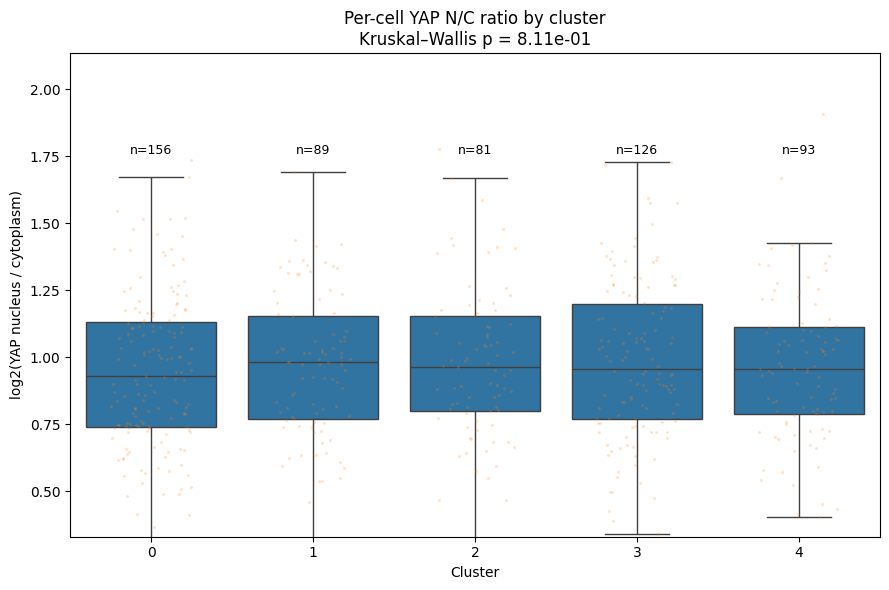

In [97]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------
df = SD_clean_no_outliers.copy()   # <- replace with your dataframe in the other notebook
cluster_col = "cluster_agg_k5"     # <- replace if your cluster column has another name

nuclear_mean_col = "dapi_Intensity_MeanIntensity_YAP"
whole_mean_col   = "yap_Intensity_MeanIntensity_YAP"
nuclear_area_col = "dapi_AreaShape_Area"
whole_area_col   = "yap_AreaShape_Area"

# --------------------------------------------------
# BUILD plot_df
# --------------------------------------------------
plot_df = df[
    [cluster_col, nuclear_mean_col, whole_mean_col, nuclear_area_col, whole_area_col]
].copy()

plot_df["cyto_area"] = plot_df[whole_area_col] - plot_df[nuclear_area_col]

plot_df["nuclear_integrated_from_mean"] = (
    plot_df[nuclear_mean_col] * plot_df[nuclear_area_col]
)
plot_df["whole_integrated_from_mean"] = (
    plot_df[whole_mean_col] * plot_df[whole_area_col]
)
plot_df["cyto_integrated_from_mean"] = (
    plot_df["whole_integrated_from_mean"] - plot_df["nuclear_integrated_from_mean"]
)
plot_df["cyto_mean_yap"] = (
    plot_df["cyto_integrated_from_mean"] / plot_df["cyto_area"]
)

plot_df["yap_nc_ratio"] = (
    plot_df[nuclear_mean_col] / plot_df["cyto_mean_yap"]
)

invalid = (
    (plot_df[nuclear_area_col] <= 0) |
    (plot_df[whole_area_col] <= 0) |
    (plot_df["cyto_area"] <= 0) |
    (plot_df[nuclear_mean_col] < 0) |
    (plot_df[whole_mean_col] < 0) |
    (plot_df["cyto_mean_yap"] <= 0)
)

plot_df.loc[invalid, "yap_nc_ratio"] = np.nan
plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
plot_df = plot_df.dropna(subset=["yap_nc_ratio"]).copy()

plot_df["log2_yap_nc_ratio"] = np.log2(plot_df["yap_nc_ratio"])
plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
plot_df = plot_df.dropna(subset=["log2_yap_nc_ratio"]).copy()

# --------------------------------------------------
# BH correction
# --------------------------------------------------
def p_to_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return "ns"

def benjamini_hochberg(pvals, alpha=0.05):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)

    if n == 0:
        return np.array([]), np.array([], dtype=bool)

    order = np.argsort(pvals)
    ranked_pvals = pvals[order]
    ranks = np.arange(1, n + 1)

    adj = ranked_pvals * n / ranks
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    adj = np.clip(adj, 0, 1)

    reject_ranked = ranked_pvals <= (ranks / n) * alpha

    adj_original = np.empty(n, dtype=float)
    reject_original = np.empty(n, dtype=bool)

    adj_original[order] = adj
    reject_original[order] = reject_ranked

    return adj_original, reject_original

# --------------------------------------------------
# STATS
# --------------------------------------------------
value_col = "log2_yap_nc_ratio"
cluster_order = sorted(plot_df[cluster_col].dropna().unique())

groups = [
    plot_df.loc[plot_df[cluster_col] == cl, value_col].dropna().values
    for cl in cluster_order
]

kw_stat, kw_p = kruskal(*groups)
print(f"Global Kruskal-Wallis p = {kw_p:.3e}")

pairwise_results = []
for c1, c2 in combinations(cluster_order, 2):
    x = plot_df.loc[plot_df[cluster_col] == c1, value_col].dropna().values
    y = plot_df.loc[plot_df[cluster_col] == c2, value_col].dropna().values

    if len(x) == 0 or len(y) == 0:
        continue

    stat, p = mannwhitneyu(x, y, alternative="two-sided")
    pairwise_results.append({
        "cluster1": c1,
        "cluster2": c2,
        "p_raw": p
    })

pairwise_df = pd.DataFrame(pairwise_results)

if not pairwise_df.empty:
    p_adj, reject = benjamini_hochberg(pairwise_df["p_raw"].values, alpha=0.05)
    pairwise_df["p_adj"] = p_adj
    pairwise_df["significant"] = reject
    pairwise_df["stars"] = pairwise_df["p_adj"].apply(p_to_stars)
    pairwise_df = pairwise_df.sort_values("p_adj")

print(pairwise_df)

# --------------------------------------------------
# PLOT
# --------------------------------------------------
plt.figure(figsize=(9, 6))
ax = sns.boxplot(
    data=plot_df,
    x=cluster_col,
    y=value_col,
    order=cluster_order,
    showfliers=False
)

sns.stripplot(
    data=plot_df,
    x=cluster_col,
    y=value_col,
    order=cluster_order,
    alpha=0.25,
    size=2,
    jitter=0.25
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Cluster")
plt.ylabel("log2(YAP nucleus / cytoplasm)")
plt.title(f"Per-cell YAP N/C ratio by cluster\nKruskal–Wallis p = {kw_p:.2e}")

ymax_data = plot_df[value_col].quantile(0.99)
ymin_data = plot_df[value_col].quantile(0.01)
yrange = ymax_data - ymin_data if ymax_data > ymin_data else 1

for i, cl in enumerate(cluster_order):
    n_cells = int((plot_df[cluster_col] == cl).sum())
    ax.text(i, ymax_data + 0.05 * yrange, f"n={n_cells}", ha="center", va="bottom", fontsize=9)

sig_pairs = pairwise_df[pairwise_df["significant"]].head(6)

base_height = ymax_data + 0.15 * yrange
step = 0.10 * yrange
bar_height = 0.03 * yrange

for idx, row in enumerate(sig_pairs.itertuples(index=False)):
    x1 = cluster_order.index(row.cluster1)
    x2 = cluster_order.index(row.cluster2)
    y = base_height + idx * step

    ax.plot([x1, x1, x2, x2], [y, y + bar_height, y + bar_height, y], lw=1.2, c="black")
    ax.text((x1 + x2) / 2, y + bar_height + 0.01 * yrange, row.stars,
            ha="center", va="bottom", fontsize=10)

plt.ylim(ymin_data - 0.05 * yrange, ymax_data + 0.25 * yrange + max(len(sig_pairs), 1) * step)
plt.tight_layout()
plt.show()

Pseudolocation summary for Feature 1476
Input cells:                  878
Cells with valid profiles:    878
Retention in plotting table:  100.00%

       n_samples  span_um  mean_width_um  median_width_um  min_width_um  \
count     878.00   878.00         878.00           878.00        878.00   
mean       15.44    17.29           5.52             5.25          2.36   
std         2.80     3.13           0.49             0.61          0.51   
min         7.00     7.84           3.86             3.64          1.68   
25%        14.00    15.68           5.26             4.76          2.24   
50%        15.00    16.80           5.48             5.32          2.24   
75%        17.00    19.04           5.76             5.60          2.24   
max        27.00    30.24           7.63             7.28          6.16   

       max_width_um  std_width_um  
count        878.00        878.00  
mean          10.82          2.35  
std            0.98          0.28  
min            5.60          0.95

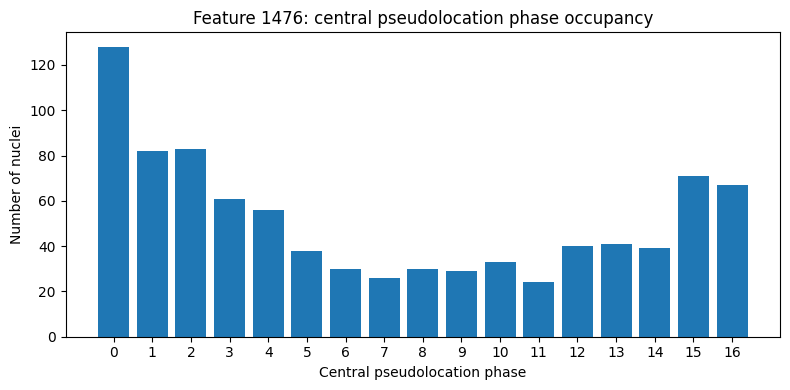

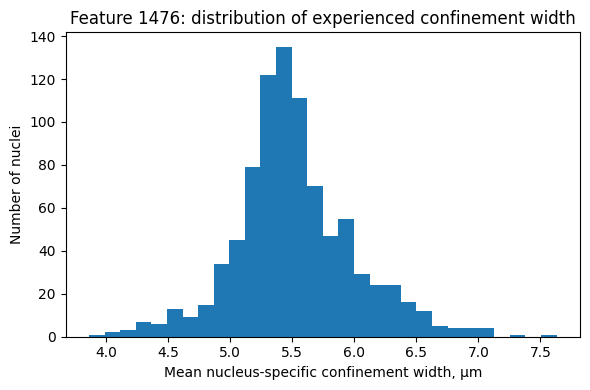

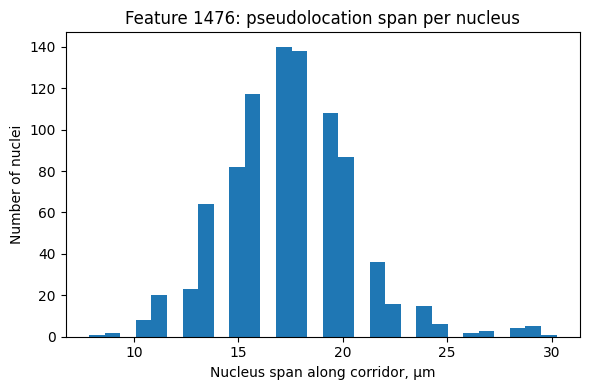

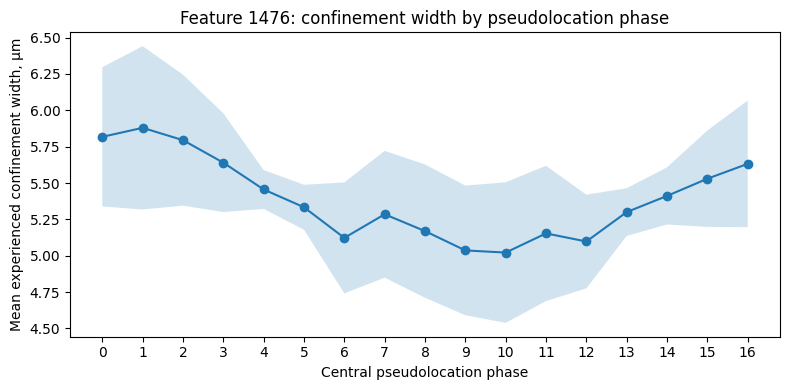

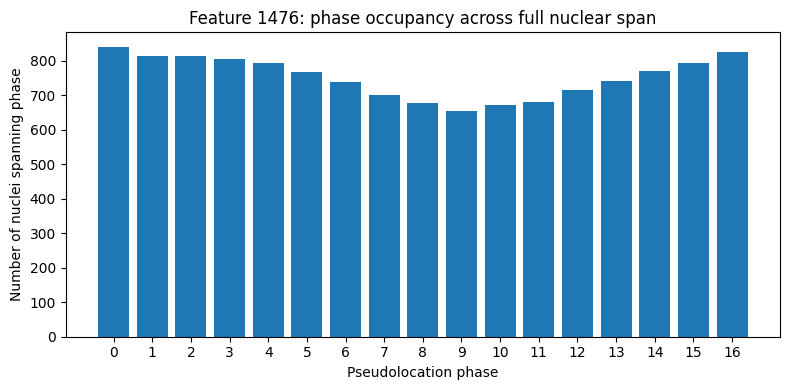

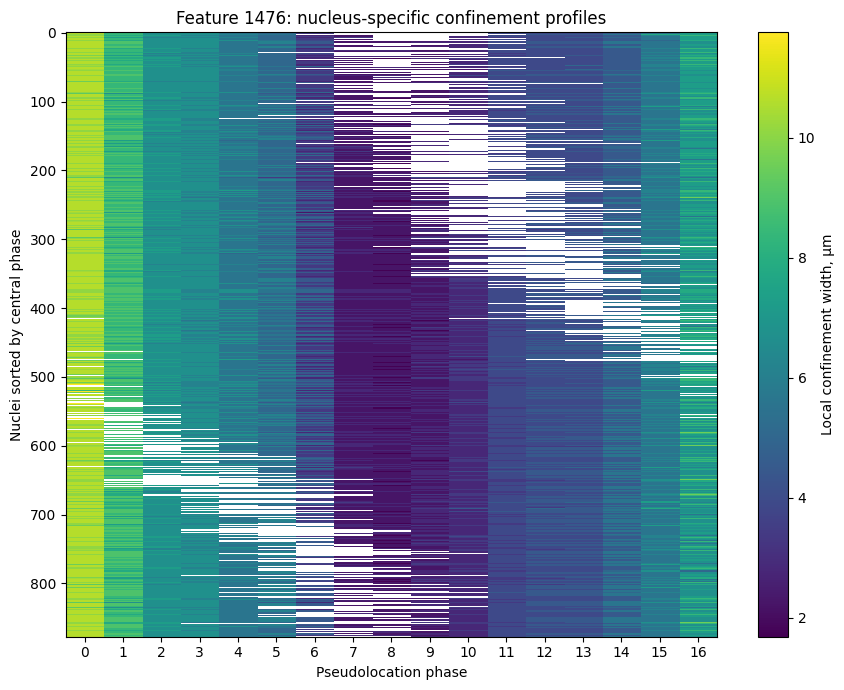

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Helper functions
# ============================================================

def parse_array(x, dtype=float):
    """
    Converts list/array/string-stored array into a numpy array.
    Works for columns such as pseudotime and pseudotime_widths.
    """
    if isinstance(x, np.ndarray):
        return x.astype(dtype)

    if isinstance(x, list):
        return np.asarray(x, dtype=dtype)

    if isinstance(x, str):
        s = (
            x.replace("\n", " ")
             .replace(",", " ")
             .replace("[", " ")
             .replace("]", " ")
             .strip()
        )
        if s == "":
            return np.array([], dtype=dtype)
        return np.fromstring(s, sep=" ", dtype=dtype)

    if pd.isna(x):
        return np.array([], dtype=dtype)

    return np.asarray(x, dtype=dtype)


def profile_to_phase_bins(phases, widths, n_bins=17):
    """
    Converts one nucleus-specific pseudolocation profile into a fixed-length
    vector of length n_bins.

    Each bin corresponds to one pseudolocation phase.
    If a nucleus has multiple sampled points in the same phase bin,
    their widths are averaged.
    """
    phases = parse_array(phases, dtype=int)
    widths = parse_array(widths, dtype=float)

    out = np.full(n_bins, np.nan)

    if len(phases) == 0 or len(widths) == 0 or len(phases) != len(widths):
        return out

    for b in range(n_bins):
        vals = widths[phases == b]
        if len(vals) > 0:
            out[b] = np.nanmean(vals)

    return out


def build_pseudolocation_summary(
    df,
    phase_col="pseudotime",
    width_col="pseudotime_widths",
    center_col="pseudotime_center_bin",
    n_bins=17,
    pixel_size_um=0.56,
    widths_are_pixels=True
):
    """
    Builds a clean dataframe with general pseudolocation descriptors per nucleus.
    """

    rows = []

    for idx, row in df.iterrows():
        phases = parse_array(row[phase_col], dtype=int)
        widths = parse_array(row[width_col], dtype=float)

        if len(phases) == 0 or len(widths) == 0 or len(phases) != len(widths):
            continue

        if widths_are_pixels:
            widths_um = widths * pixel_size_um
        else:
            widths_um = widths

        center_phase = row[center_col]

        rows.append({
            "index": idx,
            "n_samples": len(widths_um),
            "span_um": len(widths_um) * 2 * pixel_size_um,
            "center_phase": center_phase,
            "mean_width_um": np.nanmean(widths_um),
            "median_width_um": np.nanmedian(widths_um),
            "min_width_um": np.nanmin(widths_um),
            "max_width_um": np.nanmax(widths_um),
            "std_width_um": np.nanstd(widths_um),
            "phase_start": phases[0],
            "phase_end": phases[-1],
        })

    summary = pd.DataFrame(rows).set_index("index")

    phase_matrix = np.vstack([
        profile_to_phase_bins(
            row[phase_col],
            parse_array(row[width_col], dtype=float) * pixel_size_um
            if widths_are_pixels else row[width_col],
            n_bins=n_bins
        )
        for _, row in df.loc[summary.index].iterrows()
    ])

    return summary, phase_matrix


# ============================================================
# Main plotting function
# ============================================================

def plot_pseudolocation_surface_summary(
    df,
    surface_name="surface",
    phase_col="pseudotime",
    width_col="pseudotime_widths",
    center_col="pseudotime_center_bin",
    n_bins=17,
    pixel_size_um=0.56,
    widths_are_pixels=True,
    save_prefix=None
):
    """
    Plots general information about what pseudolocation/confinement
    cells experience on a given topographical surface.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing pseudolocation columns.
    surface_name : str
        Name used in plot titles, e.g. "Feature 1462".
    phase_col : str
        Column containing pseudolocation phase profile.
    width_col : str
        Column containing nucleus-specific confinement widths.
    center_col : str
        Column containing central pseudolocation phase.
    n_bins : int
        Number of phase bins in one confinement unit.
    pixel_size_um : float
        Pixel size in micrometers.
    widths_are_pixels : bool
        Set True if pseudotime_widths are stored in pixels.
        Set False if they are already in micrometers.
    save_prefix : str or None
        If provided, figures are saved using this prefix.
    """

    summary, phase_matrix = build_pseudolocation_summary(
        df=df,
        phase_col=phase_col,
        width_col=width_col,
        center_col=center_col,
        n_bins=n_bins,
        pixel_size_um=pixel_size_um,
        widths_are_pixels=widths_are_pixels
    )

    print("============================================")
    print(f"Pseudolocation summary for {surface_name}")
    print("============================================")
    print(f"Input cells:                  {len(df)}")
    print(f"Cells with valid profiles:    {len(summary)}")
    print(f"Retention in plotting table:  {len(summary) / len(df) * 100:.2f}%")
    print()
    print(summary[
        [
            "n_samples",
            "span_um",
            "mean_width_um",
            "median_width_um",
            "min_width_um",
            "max_width_um",
            "std_width_um"
        ]
    ].describe().round(2))

    # --------------------------------------------------------
    # Plot 1: central pseudolocation phase occupancy
    # --------------------------------------------------------
    center_values = pd.to_numeric(summary["center_phase"], errors="coerce").dropna().astype(int)

    counts = np.zeros(n_bins, dtype=int)
    for b in center_values:
        if 0 <= b < n_bins:
            counts[b] += 1

    plt.figure(figsize=(8, 4))
    plt.bar(np.arange(n_bins), counts)
    plt.xlabel("Central pseudolocation phase")
    plt.ylabel("Number of nuclei")
    plt.title(f"{surface_name}: central pseudolocation phase occupancy")
    plt.xticks(np.arange(n_bins))
    plt.tight_layout()

    if save_prefix is not None:
        plt.savefig(f"{save_prefix}_central_phase_occupancy.png", dpi=300)

    plt.show()

    # --------------------------------------------------------
    # Plot 2: mean confinement width experienced by each nucleus
    # --------------------------------------------------------
    plt.figure(figsize=(6, 4))
    plt.hist(summary["mean_width_um"].dropna(), bins=30)
    plt.xlabel("Mean nucleus-specific confinement width, µm")
    plt.ylabel("Number of nuclei")
    plt.title(f"{surface_name}: distribution of experienced confinement width")
    plt.tight_layout()

    if save_prefix is not None:
        plt.savefig(f"{save_prefix}_mean_width_distribution.png", dpi=300)

    plt.show()

    # --------------------------------------------------------
    # Plot 3: nucleus span along the corridor
    # --------------------------------------------------------
    plt.figure(figsize=(6, 4))
    plt.hist(summary["span_um"].dropna(), bins=30)
    plt.xlabel("Nucleus span along corridor, µm")
    plt.ylabel("Number of nuclei")
    plt.title(f"{surface_name}: pseudolocation span per nucleus")
    plt.tight_layout()

    if save_prefix is not None:
        plt.savefig(f"{save_prefix}_nucleus_span_distribution.png", dpi=300)

    plt.show()

    # --------------------------------------------------------
    # Plot 4: width statistics by central pseudolocation phase
    # --------------------------------------------------------
    phase_stats = (
        summary
        .dropna(subset=["center_phase", "mean_width_um"])
        .assign(center_phase=lambda x: x["center_phase"].astype(int))
        .groupby("center_phase")
        .agg(
            n=("mean_width_um", "size"),
            mean_width_um=("mean_width_um", "mean"),
            std_width_um=("mean_width_um", "std"),
            median_width_um=("mean_width_um", "median")
        )
        .reindex(np.arange(n_bins))
    )

    x = np.arange(n_bins)
    y = phase_stats["mean_width_um"].to_numpy()
    yerr = phase_stats["std_width_um"].to_numpy()

    plt.figure(figsize=(8, 4))
    plt.plot(x, y, marker="o")
    plt.fill_between(x, y - yerr, y + yerr, alpha=0.2)
    plt.xlabel("Central pseudolocation phase")
    plt.ylabel("Mean experienced confinement width, µm")
    plt.title(f"{surface_name}: confinement width by pseudolocation phase")
    plt.xticks(np.arange(n_bins))
    plt.tight_layout()

    if save_prefix is not None:
        plt.savefig(f"{save_prefix}_width_by_phase.png", dpi=300)

    plt.show()

    # --------------------------------------------------------
    # Plot 5: phase occupancy based on the full nucleus span
    # --------------------------------------------------------
    phase_occupancy = np.sum(np.isfinite(phase_matrix), axis=0)

    plt.figure(figsize=(8, 4))
    plt.bar(np.arange(n_bins), phase_occupancy)
    plt.xlabel("Pseudolocation phase")
    plt.ylabel("Number of nuclei spanning phase")
    plt.title(f"{surface_name}: phase occupancy across full nuclear span")
    plt.xticks(np.arange(n_bins))
    plt.tight_layout()

    if save_prefix is not None:
        plt.savefig(f"{save_prefix}_full_span_phase_occupancy.png", dpi=300)

    plt.show()

    # --------------------------------------------------------
    # Plot 6: heatmap of nucleus-specific confinement profiles
    # --------------------------------------------------------
    order = np.argsort(pd.to_numeric(summary["center_phase"], errors="coerce").fillna(-1).to_numpy())
    matrix_sorted = phase_matrix[order, :]

    plt.figure(figsize=(9, 7))
    plt.imshow(matrix_sorted, aspect="auto", interpolation="nearest")
    plt.colorbar(label="Local confinement width, µm")
    plt.xlabel("Pseudolocation phase")
    plt.ylabel("Nuclei sorted by central phase")
    plt.title(f"{surface_name}: nucleus-specific confinement profiles")
    plt.xticks(np.arange(n_bins))
    plt.tight_layout()

    if save_prefix is not None:
        plt.savefig(f"{save_prefix}_profile_heatmap.png", dpi=300)

    plt.show()

    return summary, phase_matrix, phase_stats


# ============================================================
# Example call for feature 1462
# ============================================================

summary_1462, phase_matrix_1462, phase_stats_1462 = plot_pseudolocation_surface_summary(
    df=SD_clean,
    surface_name="Feature 1476",
    phase_col="pseudotime",
    width_col="pseudotime_widths",
    center_col="pseudotime_center_bin",
    n_bins=17,
    pixel_size_um=0.56,
    widths_are_pixels=True,
    save_prefix=None
)